# Morphology-Protein Correlation Analysis

**Goal:** Investigate correlations between neuronal morphology (axon length, branching) and protein levels (Ferritin, NCOA4).

## Analysis Overview:
1. **Load saved data** from both analyses
2. **Merge datasets** by matching cells (file + scene + morphology_id)
3. **Calculate correlations** between:
   - Axon length vs Ferritin intensity/coverage
   - Axon length vs NCOA4 intensity/coverage
   - Branch balance (longest vs other) vs protein levels
   - Sholl complexity vs protein levels
4. **Visualize relationships** across treatments and timepoints

## Data Sources:
- **Morphology data:** `Sholl_Analysis_Output/cell_summary_statistics.csv` and `branch_summary.csv`
- **Protein data:** `Data/area_intensity_3.csv` (filtered for live cells)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from scipy import stats

# Set theme
sns.set_theme()
theme_dict = sns.plotting_context('notebook').copy()
so.Plot.config.theme.update(theme_dict)
plt.rcParams["svg.fonttype"] = "none"

print("✓ Packages loaded")

✓ Packages loaded


## 1. Load Data

Load the morphology data (Sholl analysis + branch statistics) and protein intensity data.

In [2]:
# Set paths
working_dir = Path.cwd()
morph_dir = working_dir / 'Sholl_Analysis_Output'
data_dir = working_dir / 'Data'

# Load morphology data
df_cell_summary = pd.read_csv(morph_dir / 'cell_summary_statistics.csv')
df_branches = pd.read_csv(morph_dir / 'branch_summary.csv')

# Load protein intensity data
df_protein_raw = pd.read_csv(data_dir / 'area_intensity_3.csv')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Morphology cell summaries: {len(df_cell_summary)} cells")
print(f"Branch data: {len(df_branches)} branches from {df_branches.groupby(['file', 'morphology_id']).ngroups} cells")
print(f"Protein measurements: {len(df_protein_raw)} measurements")
print("="*60)

DATA LOADED
Morphology cell summaries: 824 cells
Branch data: 5543 branches from 824 cells
Protein measurements: 666335 measurements


## 2. Prepare Morphology Data

Calculate key morphology metrics:
- Longest neurite length (axon proxy)
- Total "other" branch length
- Branch balance ratio (longest / other)
- Sholl complexity metrics

In [3]:
# Calculate branch metrics per cell
df_branch_metrics = df_branches.groupby(
    ['file', 'morphology_id', 'HIC', 'well', 'treatment', 'cell_type']
).apply(lambda x: pd.Series({
    'longest_length': x[x['branch_type'] == 'longest']['branch-distance'].sum(),
    'other_length': x[x['branch_type'] == 'other']['branch-distance'].sum(),
    'total_length': x['branch-distance'].sum(),
    'num_branches': x['num_branches'].iloc[0] if len(x) > 0 else 0,
    'has_branches': x['has_branches'].iloc[0] if len(x) > 0 else False
})).reset_index()

# Calculate branch balance ratio (longest / other)
# Add small epsilon to avoid division by zero
df_branch_metrics['branch_balance'] = df_branch_metrics['longest_length'] / (df_branch_metrics['other_length'] + 0.001)

# Merge with Sholl summary data
df_morphology = pd.merge(
    df_cell_summary,
    df_branch_metrics,
    on=['file', 'morphology_id', 'HIC', 'well', 'treatment', 'cell_type'],
    how='left'
)

# Create unique cell identifier
df_morphology['unique_cell_id'] = df_morphology['file'] + '_' + df_morphology['morphology_id'].astype(str)

print("="*60)
print("MORPHOLOGY METRICS CALCULATED")
print("="*60)
print(df_morphology[['file', 'morphology_id', 'longest_length', 'other_length',
                      'branch_balance', 'max_crossings', 'total_crossings']].head())
print(f"\nTotal cells with morphology data: {len(df_morphology)}")
print("="*60)

MORPHOLOGY METRICS CALCULATED
                                                file  morphology_id  \
0  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...              1   
1  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...              2   
2  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...              4   
3  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...              1   
4  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...              1   

   longest_length  other_length  branch_balance  max_crossings  \
0        8.699612     10.231154        0.850223              3   
1        9.295073      0.898670       10.331649              2   
2        1.600575      0.000000     1600.574544              1   
3       46.326968     72.641718        0.637737             10   
4       16.637105     28.341101        0.587010              6   

   total_crossings  
0               15  
1                9  
2                2  
3               87  
4               35  

Total cells with mo

C:\Users\timmo\AppData\Local\Temp\ipykernel_28284\1584966879.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(lambda x: pd.Series({


## 3. Prepare Protein Data

Extract per-cell Ferritin and NCOA4 metrics:
- Mean intensity (average across all puncta in cell)
- Coverage (percentage of cell area covered)
- Total puncta area
- Puncta count

In [4]:
# Extract HIC and well from scene_id
df_protein_raw['HIC'] = df_protein_raw['file'].str.extract(r'(\d{1,3})HIC')
df_protein_raw['well'] = df_protein_raw['scene'].str.extract(r'-(\w+)')

# Filter for live cells only (matching the approach in 02a notebook)
# Get cell type classification from dapi_class measurements
dapi_class_df = df_protein_raw[
    (df_protein_raw['mask_image'] == 'morph_label') &
    (df_protein_raw['intensity_image'] == 'dapi_class')
].copy()

def determine_neuron_type(row):
    """Classify neurons based on DAPI class values"""
    if row['MAX'] == 1 and row['INTEGRATED_INTENSITY'] == 1:
        return 'live cell'
    elif row['MAX'] == 2 and row['INTEGRATED_INTENSITY'] == 2:
        return 'dead cell'
    elif row['MAX'] == 3 and row['INTEGRATED_INTENSITY'] == 3:
        return 'debris'
    elif row['INTEGRATED_INTENSITY'] == 0:
        return 'fragment'
    elif row['MAX'] >= 1 and row['INTEGRATED_INTENSITY'] > 1:
        return 'cluster'
    else:
        return None

dapi_class_df['cell_type'] = dapi_class_df.apply(determine_neuron_type, axis=1)

# Get cell type mapping
cell_type_map = dapi_class_df.groupby(
    ['file', 'scene_id', 'ROI_label', 'HIC']
)['cell_type'].first().reset_index()

print("Cell type distribution:")
print(cell_type_map['cell_type'].value_counts())
print("\n" + "="*60)

Cell type distribution:
cell_type
fragment     1155
live cell    1118
cluster       171
debris         11
dead cell       1
Name: count, dtype: int64



In [5]:
# Extract Ferritin metrics per cell (intensity on morphology)
ftn_intensity = df_protein_raw[
    df_protein_raw['description'] == 'ftn_intensity_on_morph'
][['file', 'scene_id', 'ROI_label', 'HIC', 'MEAN', 'INTEGRATED_INTENSITY']].copy()
ftn_intensity.columns = ['file', 'scene_id', 'ROI_label', 'HIC', 'ftn_mean_intensity', 'ftn_integrated_intensity']

# Extract Ferritin coverage (area measurements)
ftn_coverage = df_protein_raw[
    df_protein_raw['description'] == 'ftn_area_on_morph'
][['file', 'scene_id', 'ROI_label', 'HIC', 'MEAN']].copy()
ftn_coverage.columns = ['file', 'scene_id', 'ROI_label', 'HIC', 'ftn_coverage_pct']

# Extract NCOA4 metrics per cell
ncoa4_intensity = df_protein_raw[
    df_protein_raw['description'] == 'ncoa4_intensity_on_morph'
][['file', 'scene_id', 'ROI_label', 'HIC', 'MEAN', 'INTEGRATED_INTENSITY']].copy()
ncoa4_intensity.columns = ['file', 'scene_id', 'ROI_label', 'HIC', 'ncoa4_mean_intensity', 'ncoa4_integrated_intensity']

# Extract NCOA4 coverage
ncoa4_coverage = df_protein_raw[
    df_protein_raw['description'] == 'ncoa4_area_on_morph'
][['file', 'scene_id', 'ROI_label', 'HIC', 'MEAN']].copy()
ncoa4_coverage.columns = ['file', 'scene_id', 'ROI_label', 'HIC', 'ncoa4_coverage_pct']

# Merge all protein metrics
df_protein = ftn_intensity.merge(
    ftn_coverage, on=['file', 'scene_id', 'ROI_label', 'HIC'], how='outer'
).merge(
    ncoa4_intensity, on=['file', 'scene_id', 'ROI_label', 'HIC'], how='outer'
).merge(
    ncoa4_coverage, on=['file', 'scene_id', 'ROI_label', 'HIC'], how='outer'
)

# Merge with cell type
df_protein = df_protein.merge(
    cell_type_map, on=['file', 'scene_id', 'ROI_label', 'HIC'], how='left'
)

# Filter for live cells only
df_protein_live = df_protein[df_protein['cell_type'] == 'live cell'].copy()

# ROI_label in protein data = morphology_id in morphology data
df_protein_live.rename(columns={'ROI_label': 'morphology_id'}, inplace=True)

print("="*60)
print("PROTEIN METRICS EXTRACTED")
print("="*60)
print(f"Total live cells with protein data: {len(df_protein_live)}")
print("\nSample protein data:")
print(df_protein_live[['file', 'morphology_id', 'ftn_mean_intensity',
                        'ftn_coverage_pct', 'ncoa4_mean_intensity']].head())
print("="*60)

PROTEIN METRICS EXTRACTED
Total live cells with protein data: 1118

Sample protein data:
                                                file  morphology_id  \
0  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...            1.0   
1  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...            2.0   
3  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...            4.0   
4  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...            1.0   
6  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...            1.0   

   ftn_mean_intensity  ftn_coverage_pct  ncoa4_mean_intensity  
0         1448.413289          0.000000           1632.167404  
1         1777.553869          0.000977           1699.822890  
3         1721.498490          0.000679           1891.579861  
4         2847.282093          0.184601           1693.866055  
6         1587.018340          0.056916           1711.617400  


## 4. Merge Morphology and Protein Data

Match cells using `file` + `scene_id` + `morphology_id` to create a unified dataset for correlation analysis.

In [6]:
# Need to extract scene_id from morphology file names
# File format: "2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 568 PHALL 488 DAPI OBL_0_0_P1-A9.ome"
# Scene is after the last underscore before .ome, e.g., "P1-A9"
df_morphology['scene_id'] = df_morphology['file'].str.extract(r'_(\w+-\w+)\.ome$')

# DEBUG: Check what we have before merging
print("\n" + "="*60)
print("DEBUG: CHECKING MERGE KEYS")
print("="*60)
print("\nMorphology data sample:")
print(df_morphology[['file', 'scene_id', 'morphology_id', 'HIC']].head())
print("\nMorphology data types:")
print(f"  scene_id: {df_morphology['scene_id'].dtype}")
print(f"  morphology_id: {df_morphology['morphology_id'].dtype}")
print(f"  HIC: {df_morphology['HIC'].dtype}")

print("\nProtein data sample:")
print(df_protein_live[['file', 'scene_id', 'morphology_id', 'HIC']].head())
print("\nProtein data types:")
print(f"  scene_id: {df_protein_live['scene_id'].dtype}")
print(f"  morphology_id: {df_protein_live['morphology_id'].dtype}")
print(f"  HIC: {df_protein_live['HIC'].dtype}")

# Check for unique file matches
morph_files = set(df_morphology['file'].unique())
protein_files = set(df_protein_live['file'].unique())
print("\nFile name matching:")
print(f"  Morphology files: {len(morph_files)}")
print(f"  Protein files: {len(protein_files)}")
print(f"  Files in both: {len(morph_files & protein_files)}")

# Check scene_id extraction
print("\nScene_id check:")
print(f"  Morphology scene_ids (unique): {df_morphology['scene_id'].nunique()}")
print(f"  Protein scene_ids (unique): {df_protein_live['scene_id'].nunique()}")
print(f"  Example morphology scene_ids: {df_morphology['scene_id'].unique()[:5]}")
print(f"  Example protein scene_ids: {df_protein_live['scene_id'].unique()[:5]}")
print("="*60 + "\n")

# Ensure data types match for merging
# Convert HIC to string in both dataframes to ensure compatibility
df_morphology['HIC'] = df_morphology['HIC'].astype(str)
df_protein_live['HIC'] = df_protein_live['HIC'].astype(str)

# Also ensure morphology_id is the same type in both
df_morphology['morphology_id'] = df_morphology['morphology_id'].astype(int)
df_protein_live['morphology_id'] = df_protein_live['morphology_id'].astype(int)

# Merge morphology with protein data
# NOTE: File names don't match between datasets, so we merge on scene_id, morphology_id, and HIC
# This matches cells within the same scene/well at the same timepoint
df_merged = df_morphology.merge(
    df_protein_live,
    on=['scene_id', 'morphology_id', 'HIC'],
    how='inner',  # Only keep cells that have both morphology and protein data
    suffixes=('_morph', '_protein')
)

# Set up categorical ordering for treatment
treatment_order = ['Control', '50uM DFP', '100uM DFP', '100uM DFO']
df_merged['treatment'] = pd.Categorical(
    df_merged['treatment'],
    categories=treatment_order,
    ordered=True
)

# Convert HIC to numeric for better sorting/plotting
df_merged['HIC'] = pd.to_numeric(df_merged['HIC'])
df_merged.sort_values(by=['HIC', 'treatment'], inplace=True)

print("="*60)
print("DATA MERGED")
print("="*60)
print(f"Total cells with both morphology and protein data: {len(df_merged)}")
print("\nCells by HIC:")
print(df_merged['HIC'].value_counts().sort_index())
print("\nCells by treatment:")
print(df_merged.groupby('treatment', observed=True).size())
print("="*60)

# Display sample of merged data
print("\nSample merged data:")
print(df_merged[['scene_id', 'morphology_id', 'HIC', 'treatment',
                  'longest_length', 'branch_balance', 'max_crossings',
                  'ftn_mean_intensity', 'ncoa4_mean_intensity']].head(10))


DEBUG: CHECKING MERGE KEYS

Morphology data sample:
                                                file       scene_id  \
0  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_P1-A9   
1  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_P1-A9   
2  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_P1-A9   
3  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...  100_99_P12-G9   
4  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...  101_100_P2-H9   

   morphology_id  HIC  
0              1   18  
1              2   18  
2              4   18  
3              1   18  
4              1   18  

Morphology data types:
  scene_id: object
  morphology_id: int64
  HIC: int64

Protein data sample:
                                                file       scene_id  \
0  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_P1-A9   
1  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_P1-A9   
3  2024-08-07 25x 18HIC VERSION 1 NCOA4 647 FT 56...      0_0_

## 5. Correlation Analysis

Calculate correlations between morphology and protein metrics.

CORRELATION MATRIX (Spearman)
                 ftn_mean_intensity  ftn_coverage_pct  \
longest_length               -0.022             0.206   
other_length                 -0.106             0.144   
total_length                 -0.066             0.184   
branch_balance                0.176             0.074   
max_crossings                -0.149             0.132   
total_crossings              -0.070             0.194   
skeleton_pixels              -0.075             0.194   

                 ftn_integrated_intensity  ncoa4_mean_intensity  \
longest_length                      0.698                 0.008   
other_length                        0.648                -0.010   
total_length                        0.715                 0.004   
branch_balance                     -0.063                 0.115   
max_crossings                       0.577                -0.046   
total_crossings                     0.733                 0.007   
skeleton_pixels                     0.728   

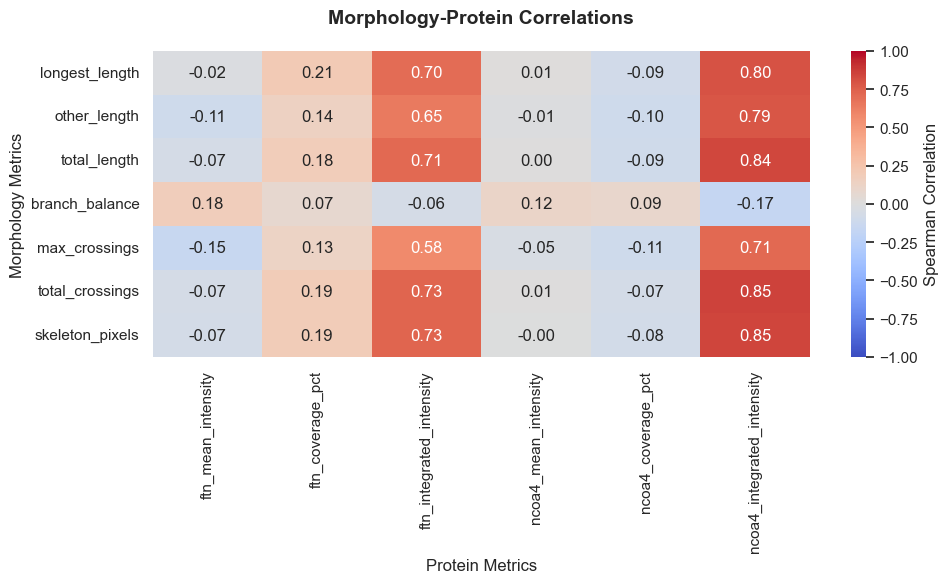

In [7]:
# Select key variables for correlation
morph_vars = ['longest_length', 'other_length', 'total_length', 'branch_balance',
              'max_crossings', 'total_crossings', 'skeleton_pixels']
protein_vars = ['ftn_mean_intensity', 'ftn_coverage_pct', 'ftn_integrated_intensity',
                'ncoa4_mean_intensity', 'ncoa4_coverage_pct', 'ncoa4_integrated_intensity']

# Calculate correlation matrix
corr_data = df_merged[morph_vars + protein_vars].copy()
corr_matrix = corr_data.corr(method='spearman')  # Use Spearman for potentially non-linear relationships

# Extract just the morphology-protein correlations
corr_subset = corr_matrix.loc[morph_vars, protein_vars]

print("="*60)
print("CORRELATION MATRIX (Spearman)")
print("="*60)
print(corr_subset.round(3))
print("="*60)

# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Spearman Correlation'},
    ax=ax
)
ax.set_title('Morphology-Protein Correlations', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Protein Metrics', fontsize=12)
ax.set_ylabel('Morphology Metrics', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Scatter Plots: Key Relationships

Visualize the most interesting correlations with treatment-specific coloring.

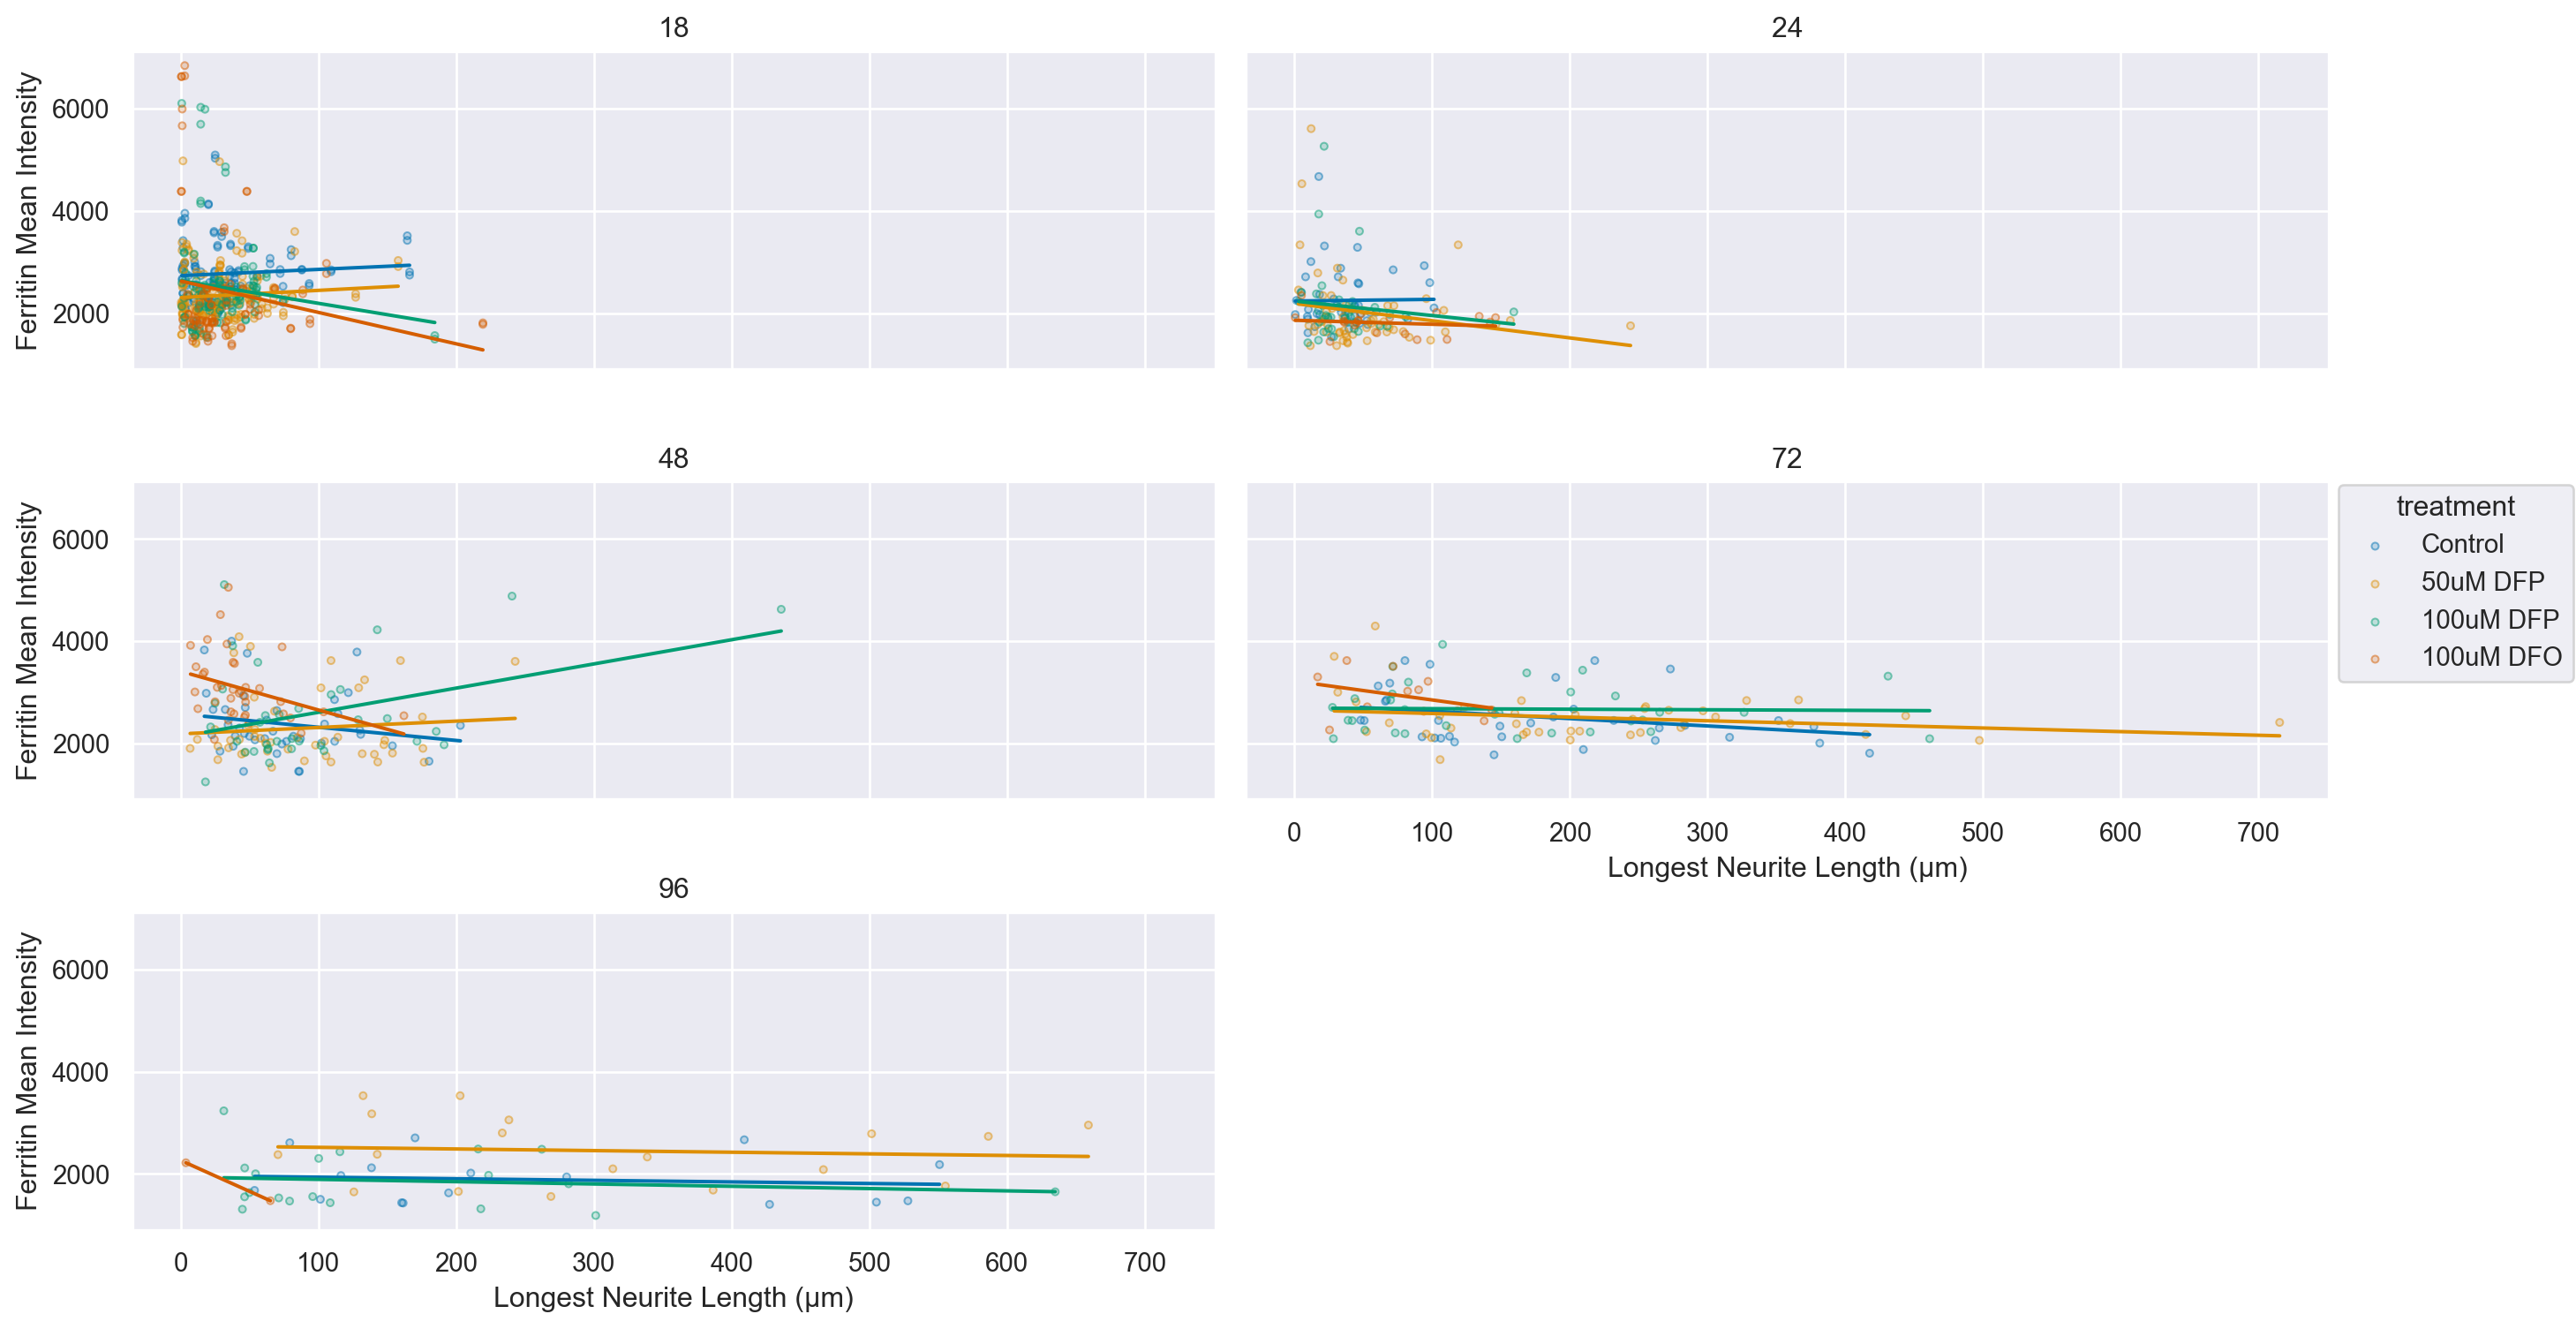

In [27]:
# Plot 1: Longest neurite length vs Ferritin intensity
(
    so.Plot(df_merged, x='longest_length', y='ftn_mean_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(color='colorblind')
    .label(
        x='Longest Neurite Length (µm)',
        y='Ferritin Mean Intensity',
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

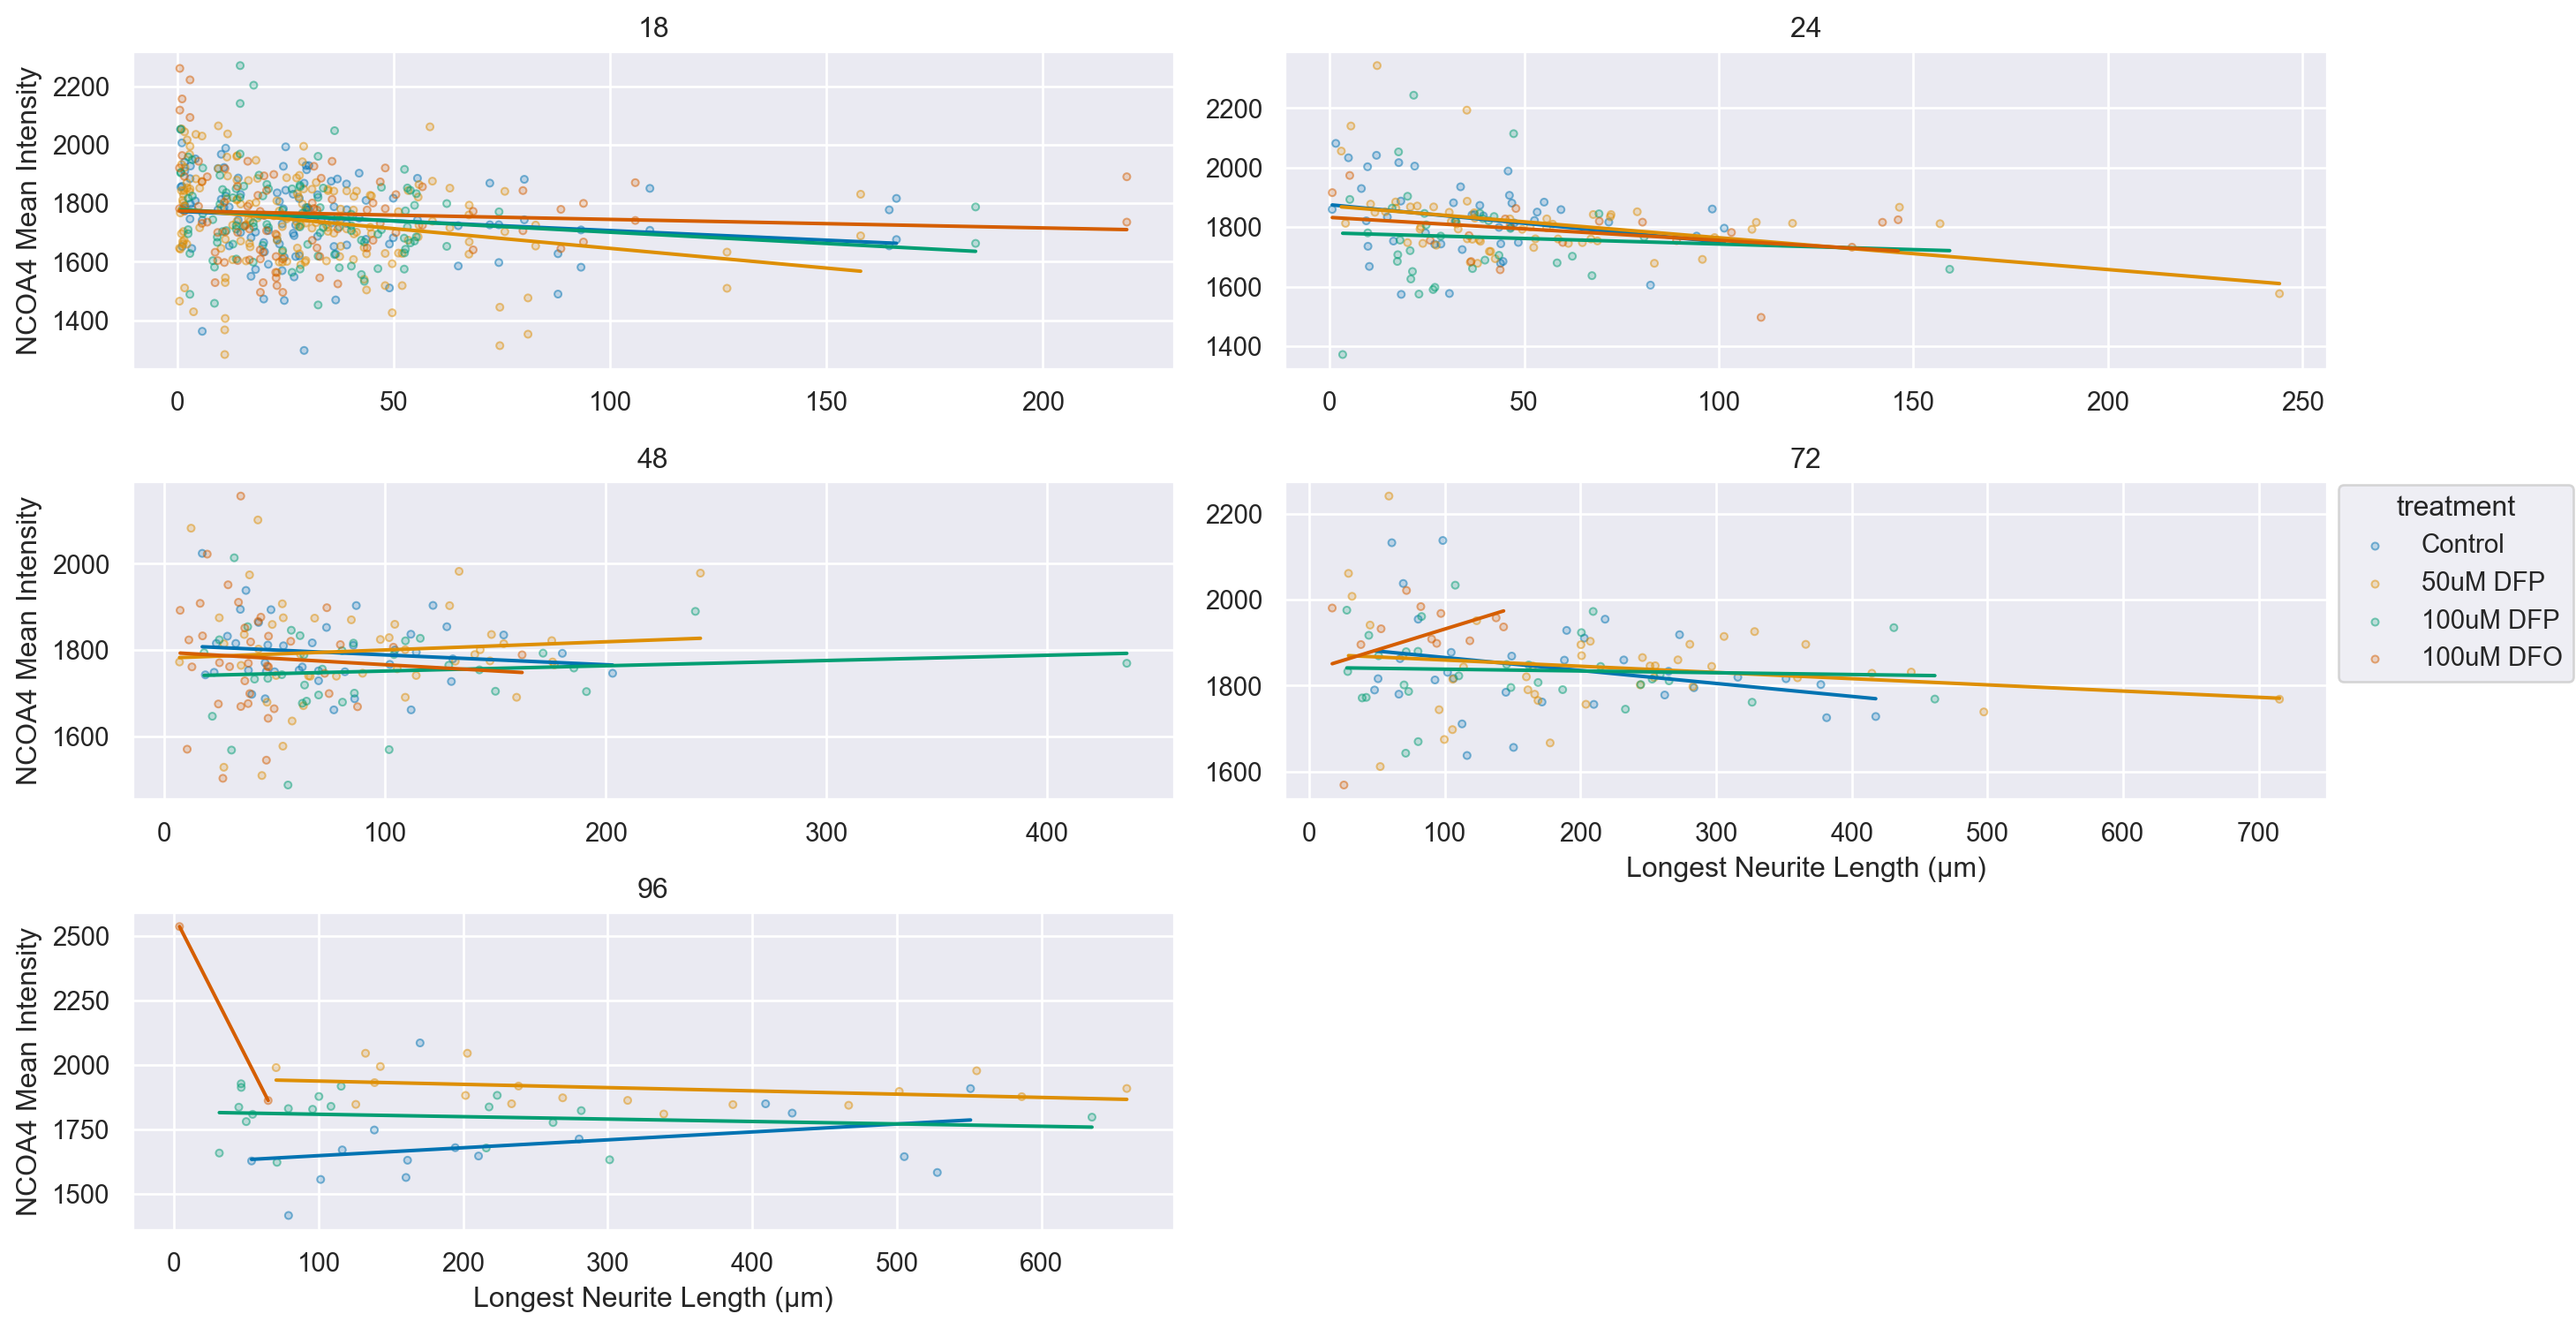

In [34]:
# Plot 2: Longest neurite length vs NCOA4 intensity
(
    so.Plot(df_merged, x='longest_length', y='ncoa4_mean_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(color='colorblind')
    .share(y=False, x=False)
    .label(
        x='Longest Neurite Length (µm)',
        y='NCOA4 Mean Intensity',
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

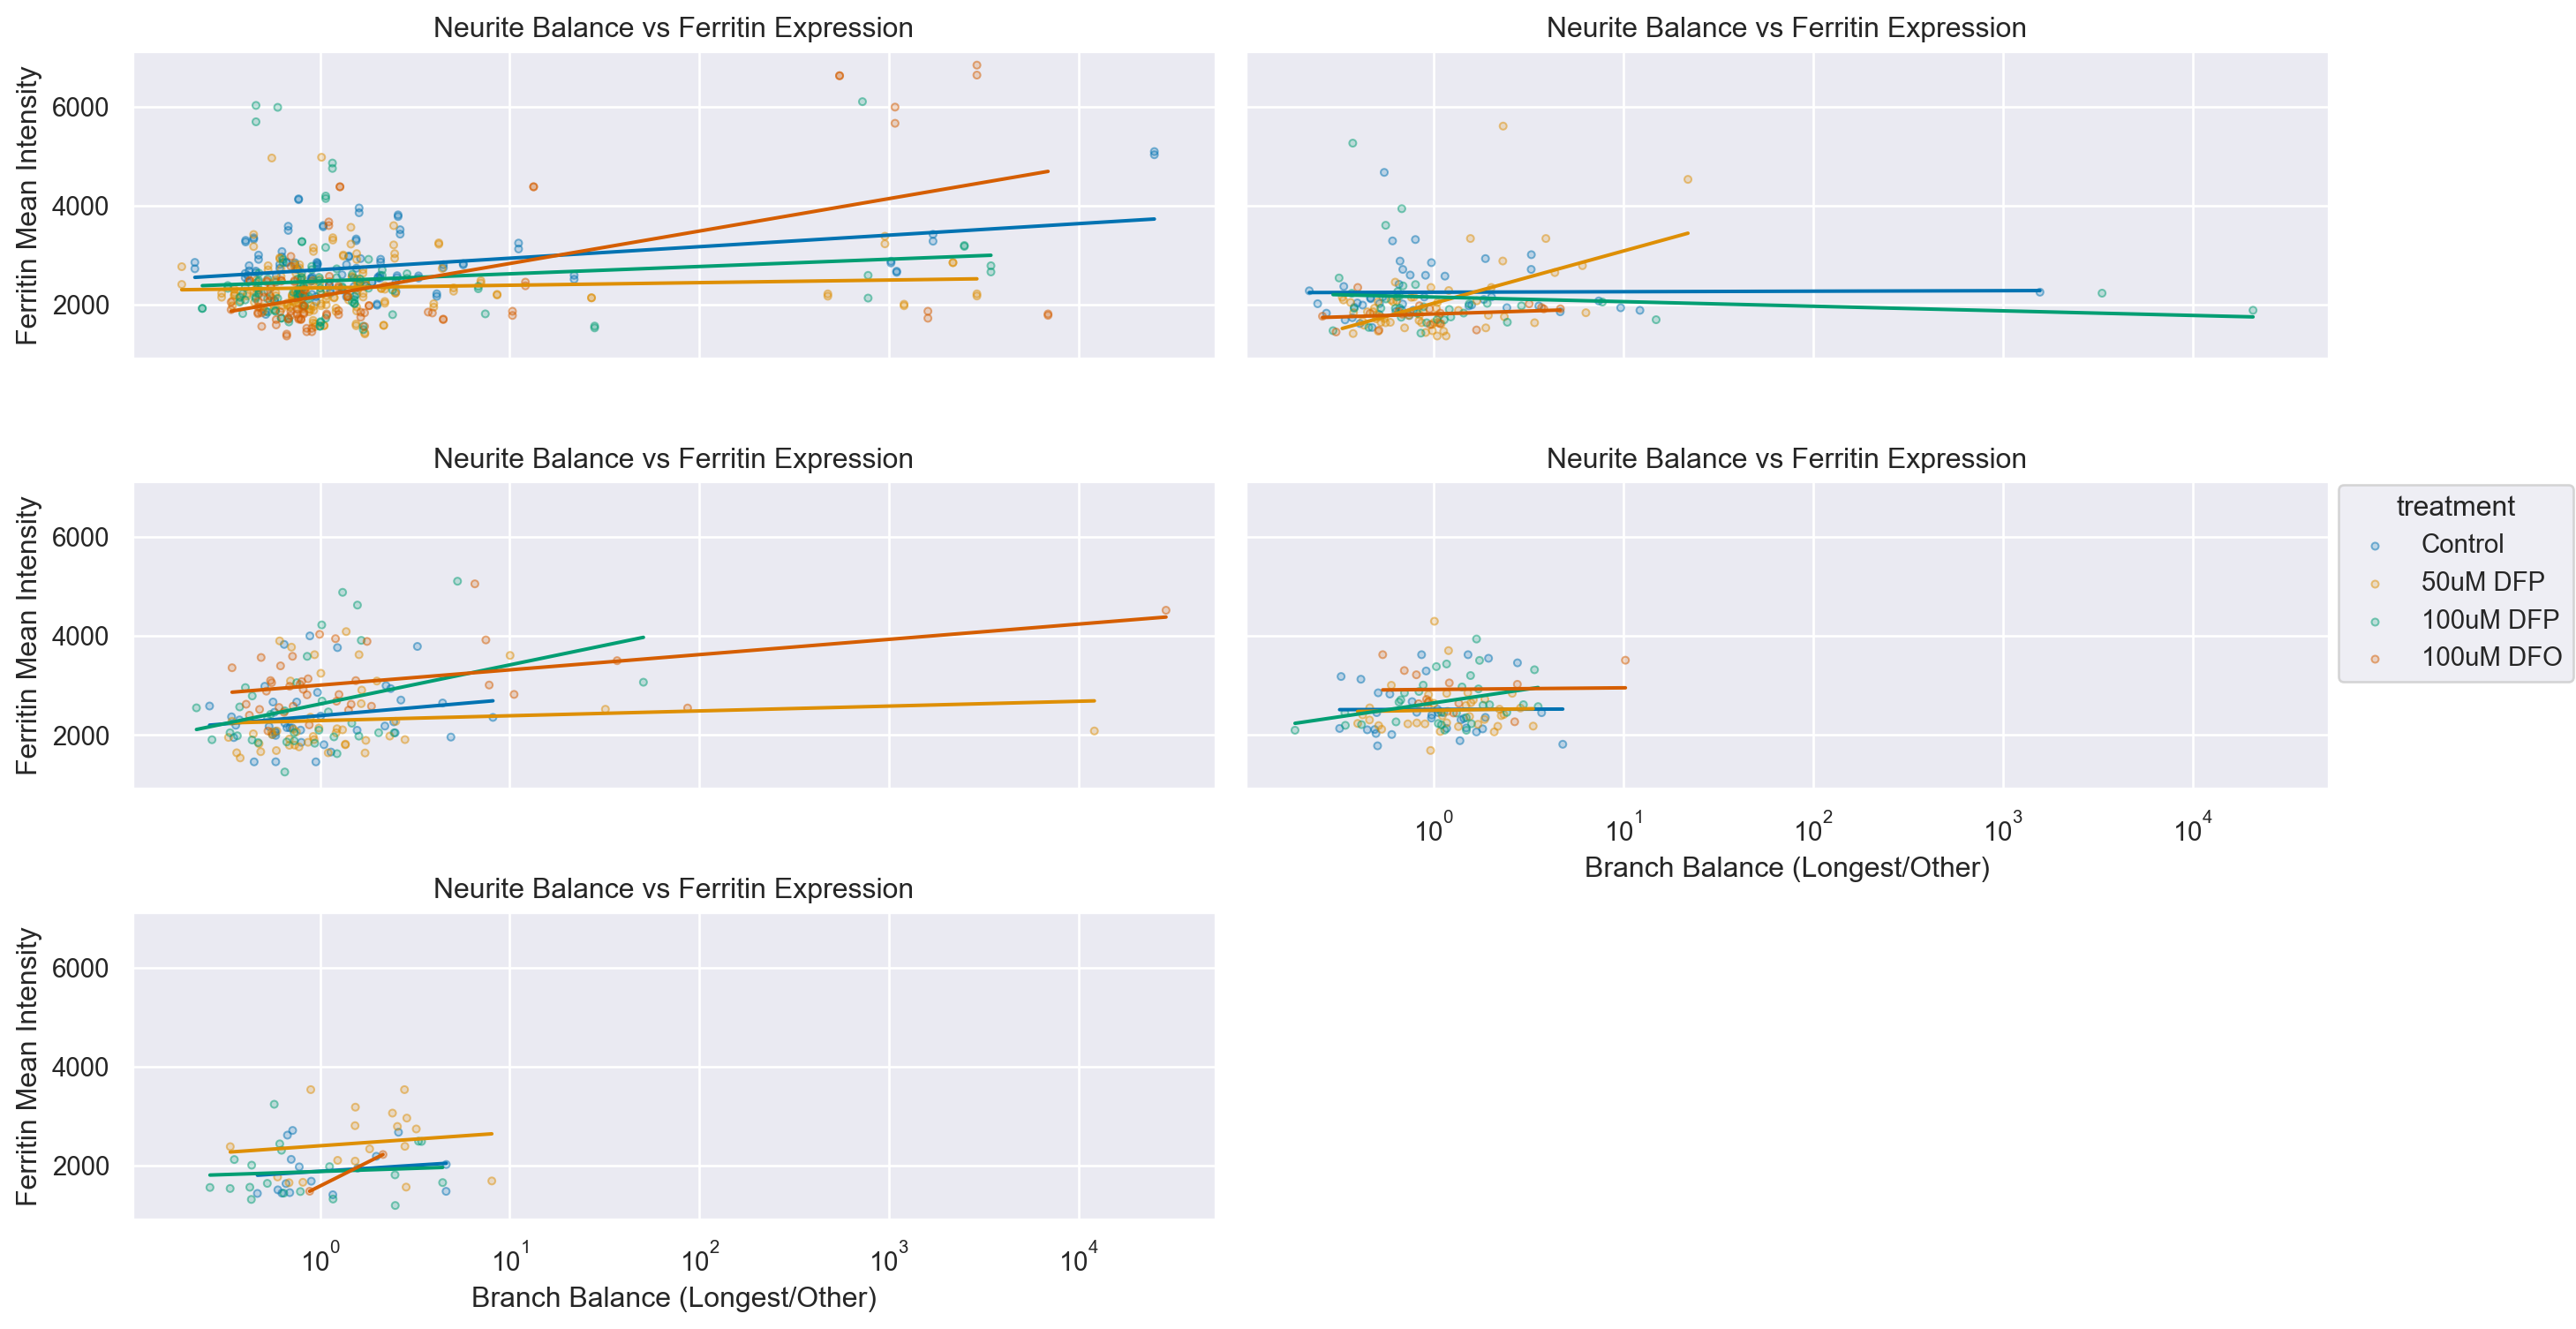

In [29]:
# Plot 3: Branch balance vs Ferritin intensity
(
    so.Plot(df_merged, x='branch_balance', y='ftn_mean_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(color='colorblind', x='log')  # Log scale for branch balance
    .label(
        x='Branch Balance (Longest/Other)',
        y='Ferritin Mean Intensity',
        title='Neurite Balance vs Ferritin Expression'
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

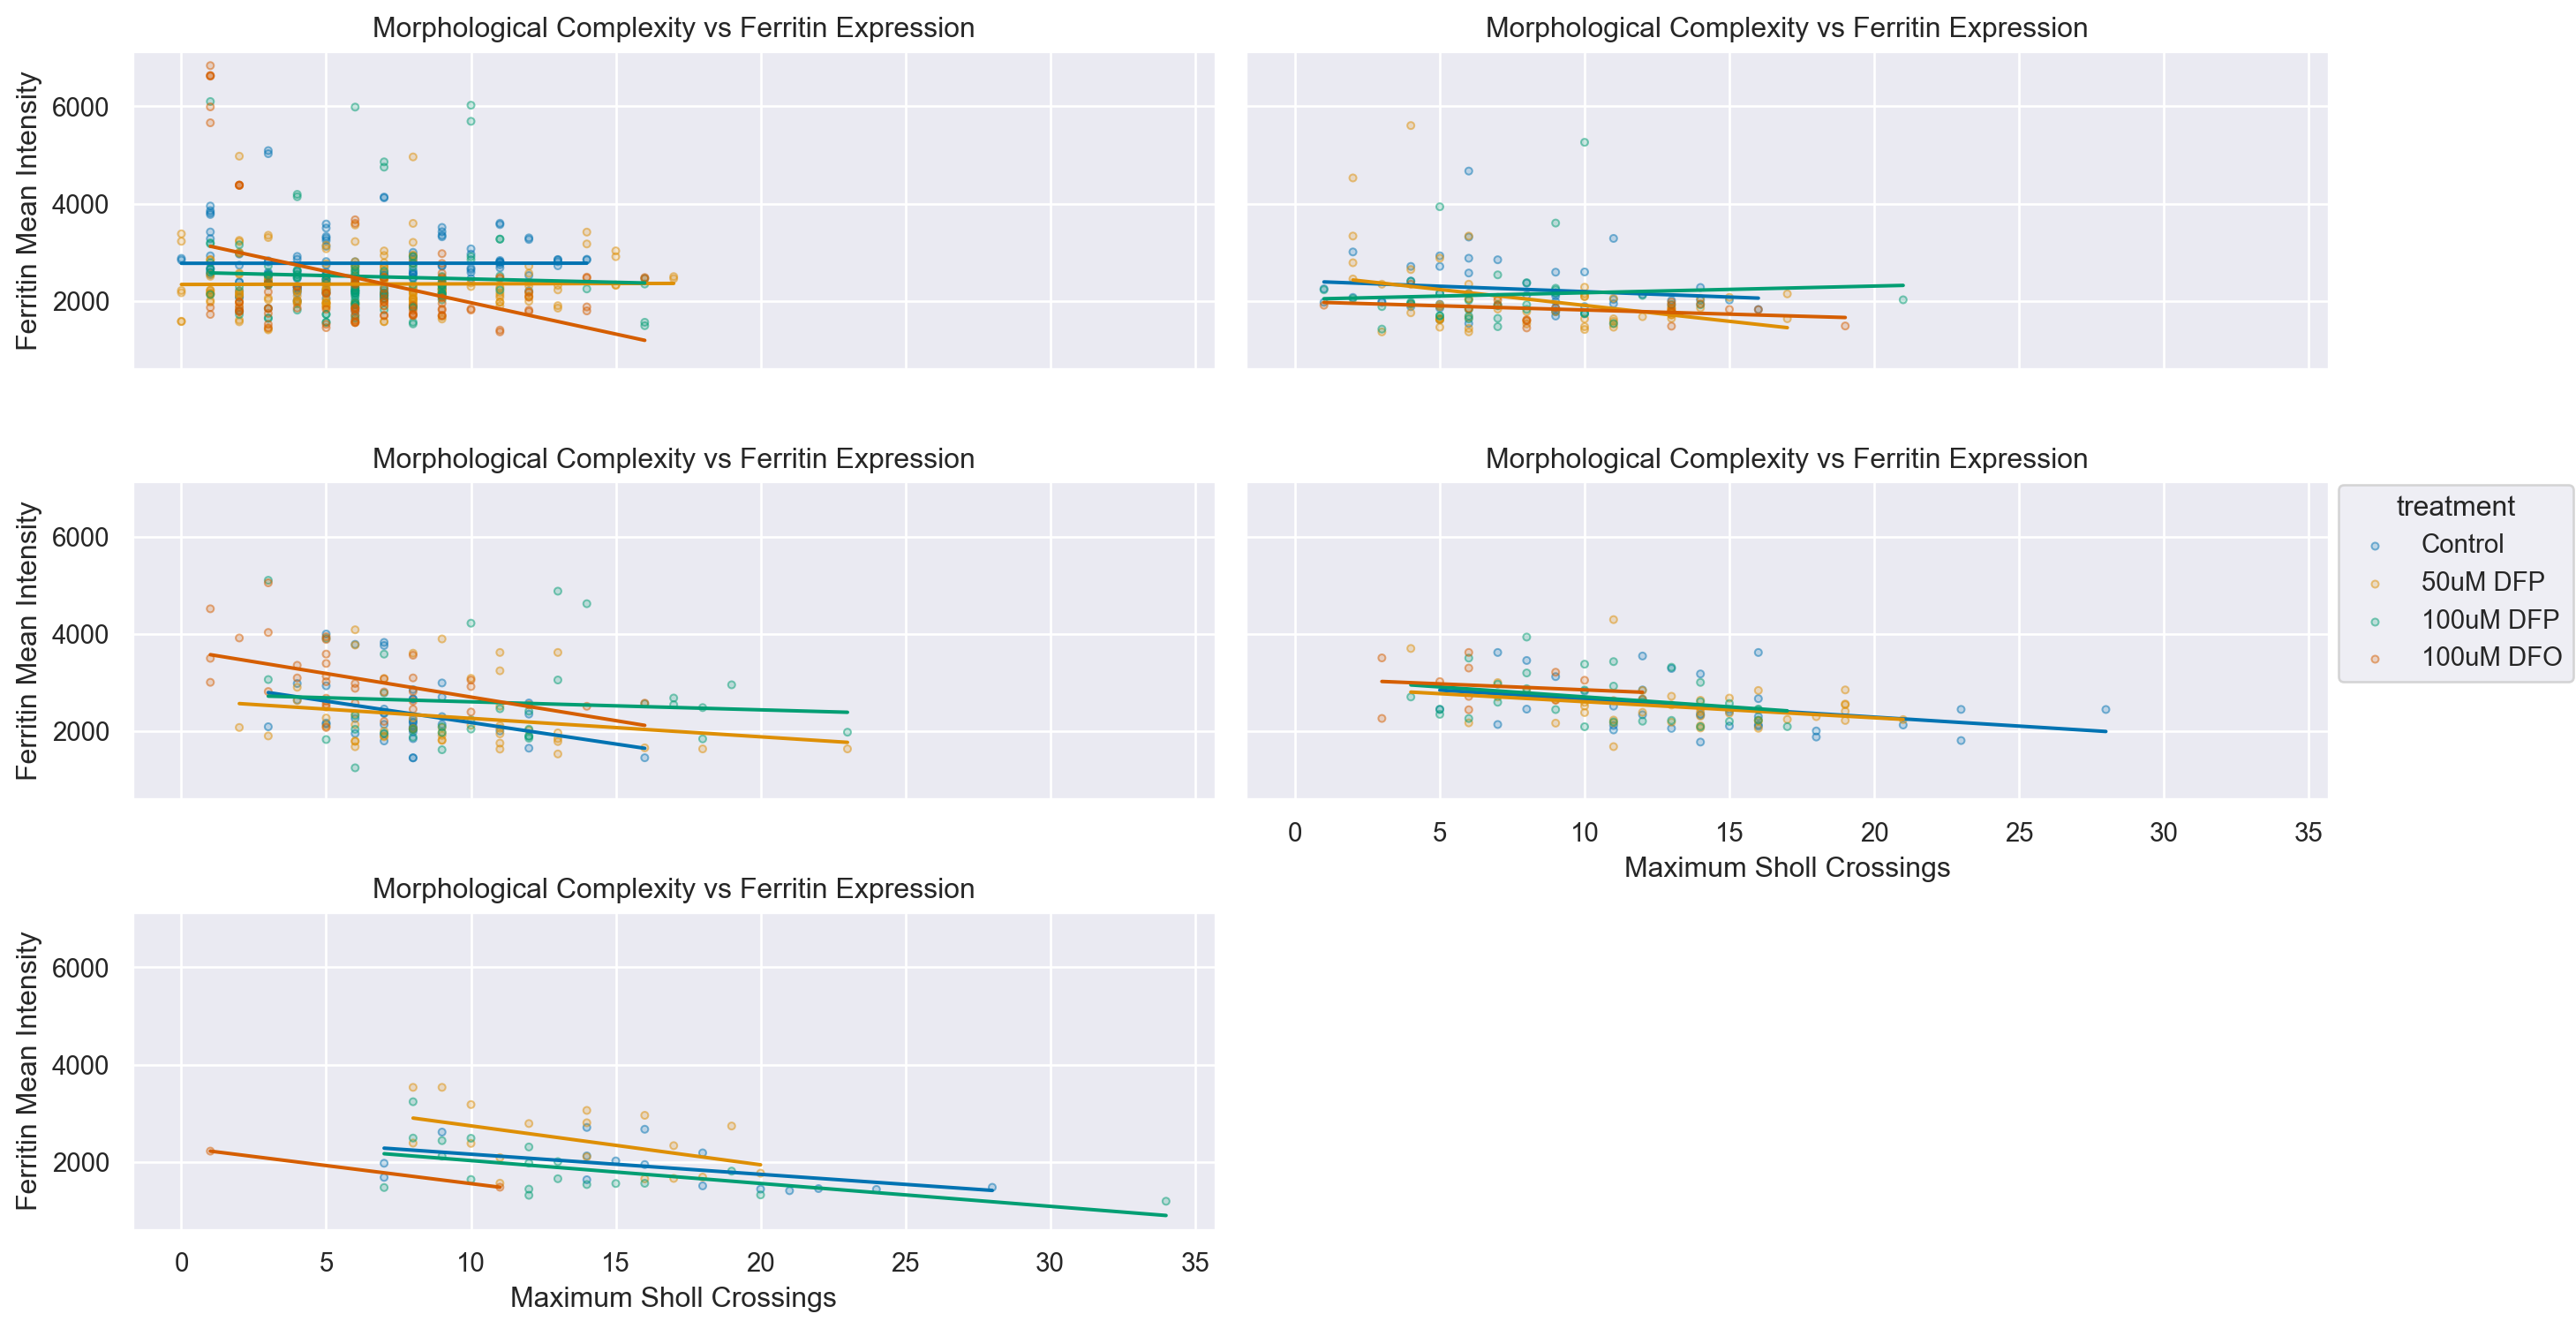

In [30]:
# Plot 4: Sholl complexity (max crossings) vs Ferritin intensity
(
    so.Plot(df_merged, x='max_crossings', y='ftn_mean_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(
        color='colorblind')
    .label(
        x='Maximum Sholl Crossings',
        y='Ferritin Mean Intensity',
        title='Morphological Complexity vs Ferritin Expression'
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

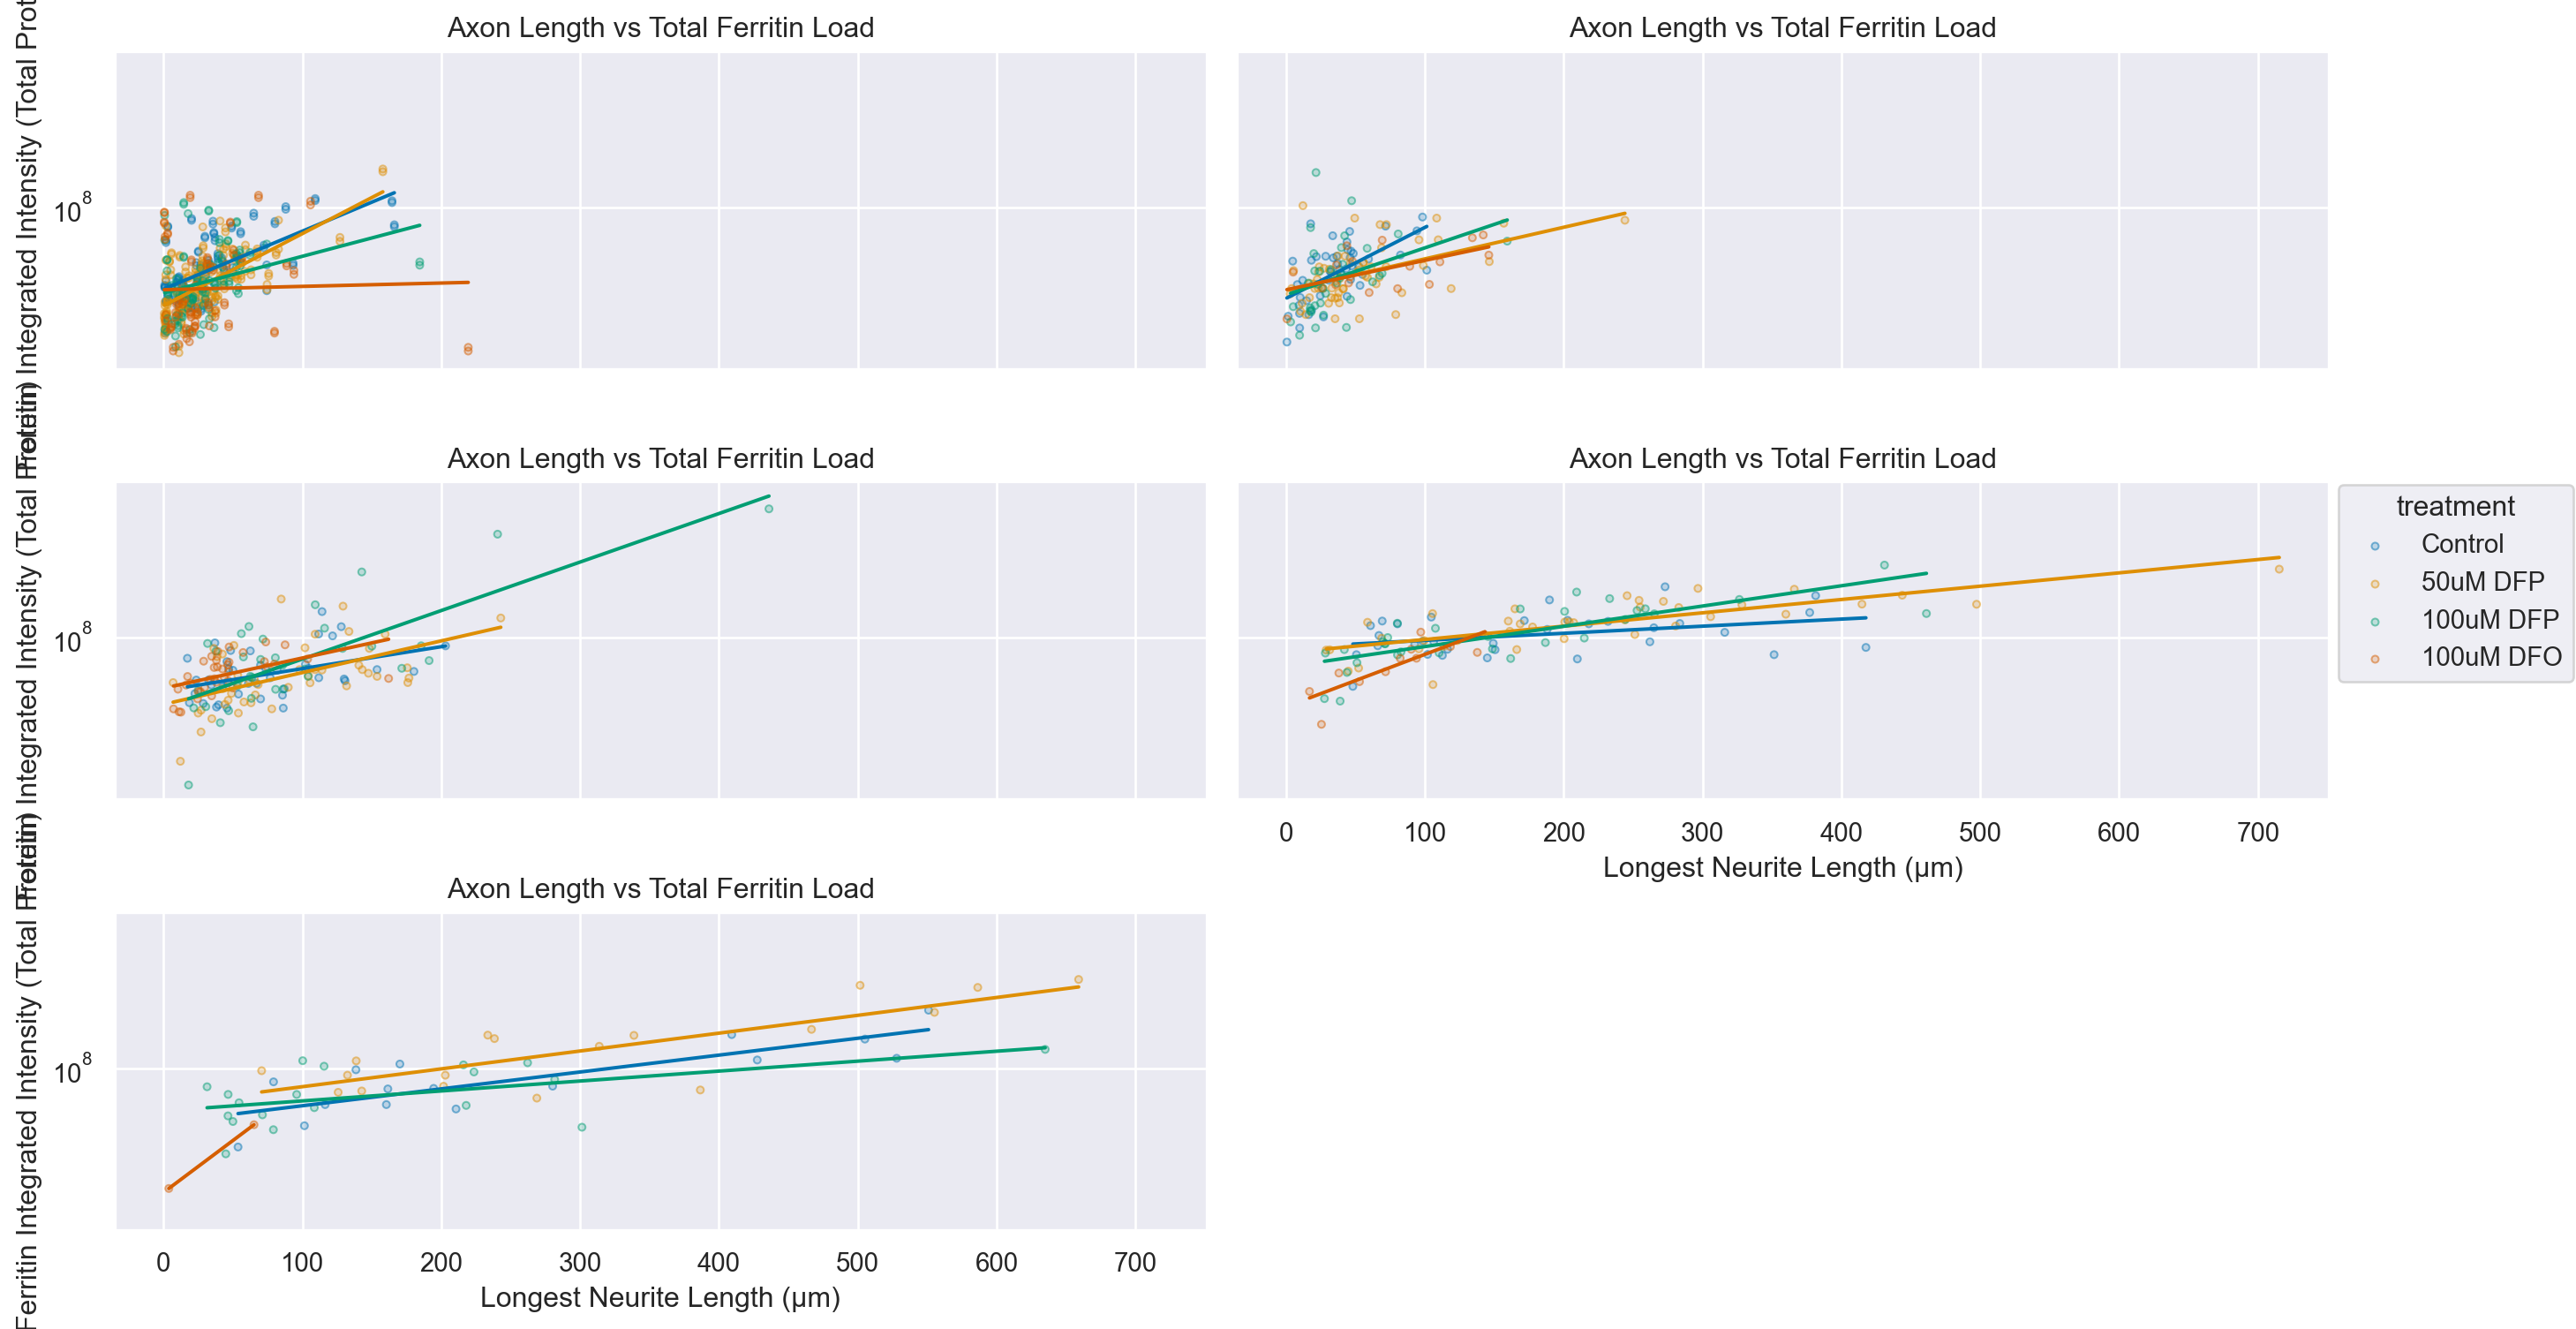

In [31]:
# Plot 5: Longest neurite length vs Ferritin INTEGRATED intensity
# Integrated intensity = total protein load (mean intensity × area)
(
    so.Plot(df_merged, x='longest_length', y='ftn_integrated_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(
        color='colorblind',
        y='log'  # Log scale for integrated intensity
    )
    .label(
        x='Longest Neurite Length (µm)',
        y='Ferritin Integrated Intensity (Total Protein)',
        title='Axon Length vs Total Ferritin Load'
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

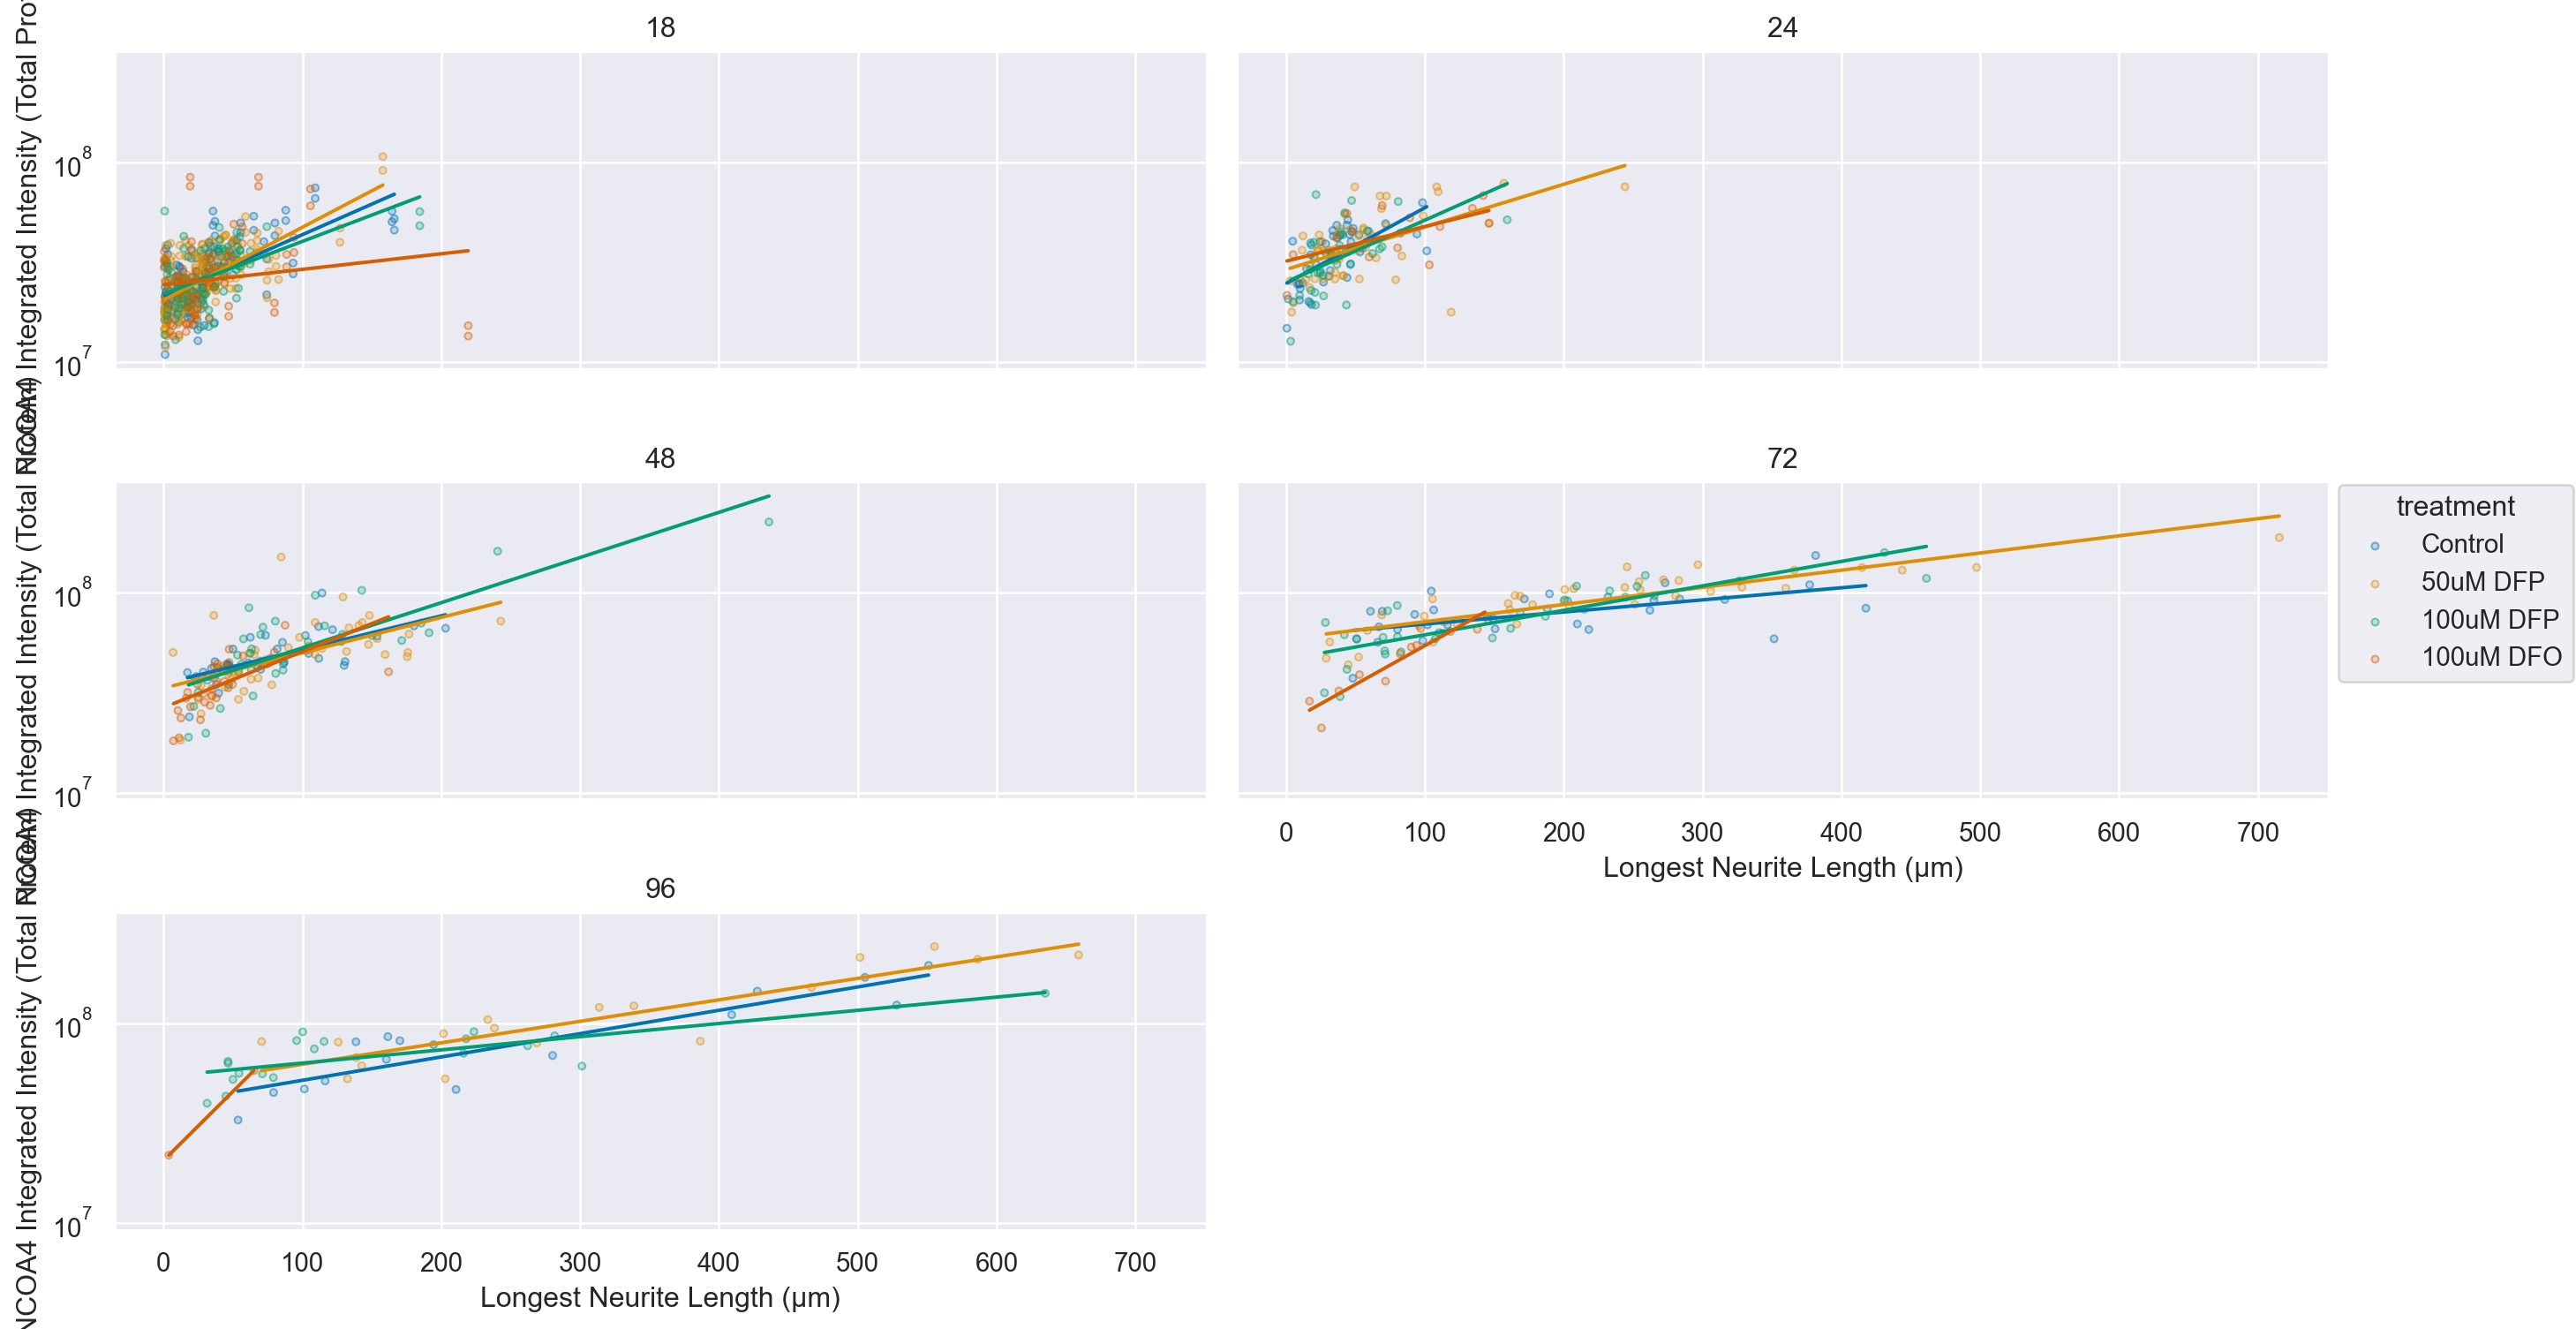

In [32]:
# Plot 6: Longest neurite length vs NCOA4 INTEGRATED intensity
# Shows total NCOA4 protein load relationship with axon length
(
    so.Plot(df_merged, x='longest_length', y='ncoa4_integrated_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(
        color='colorblind',
        y='log'  # Log scale for integrated intensity
    )
    .label(
        x='Longest Neurite Length (µm)',
        y='NCOA4 Integrated Intensity (Total Protein)',
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

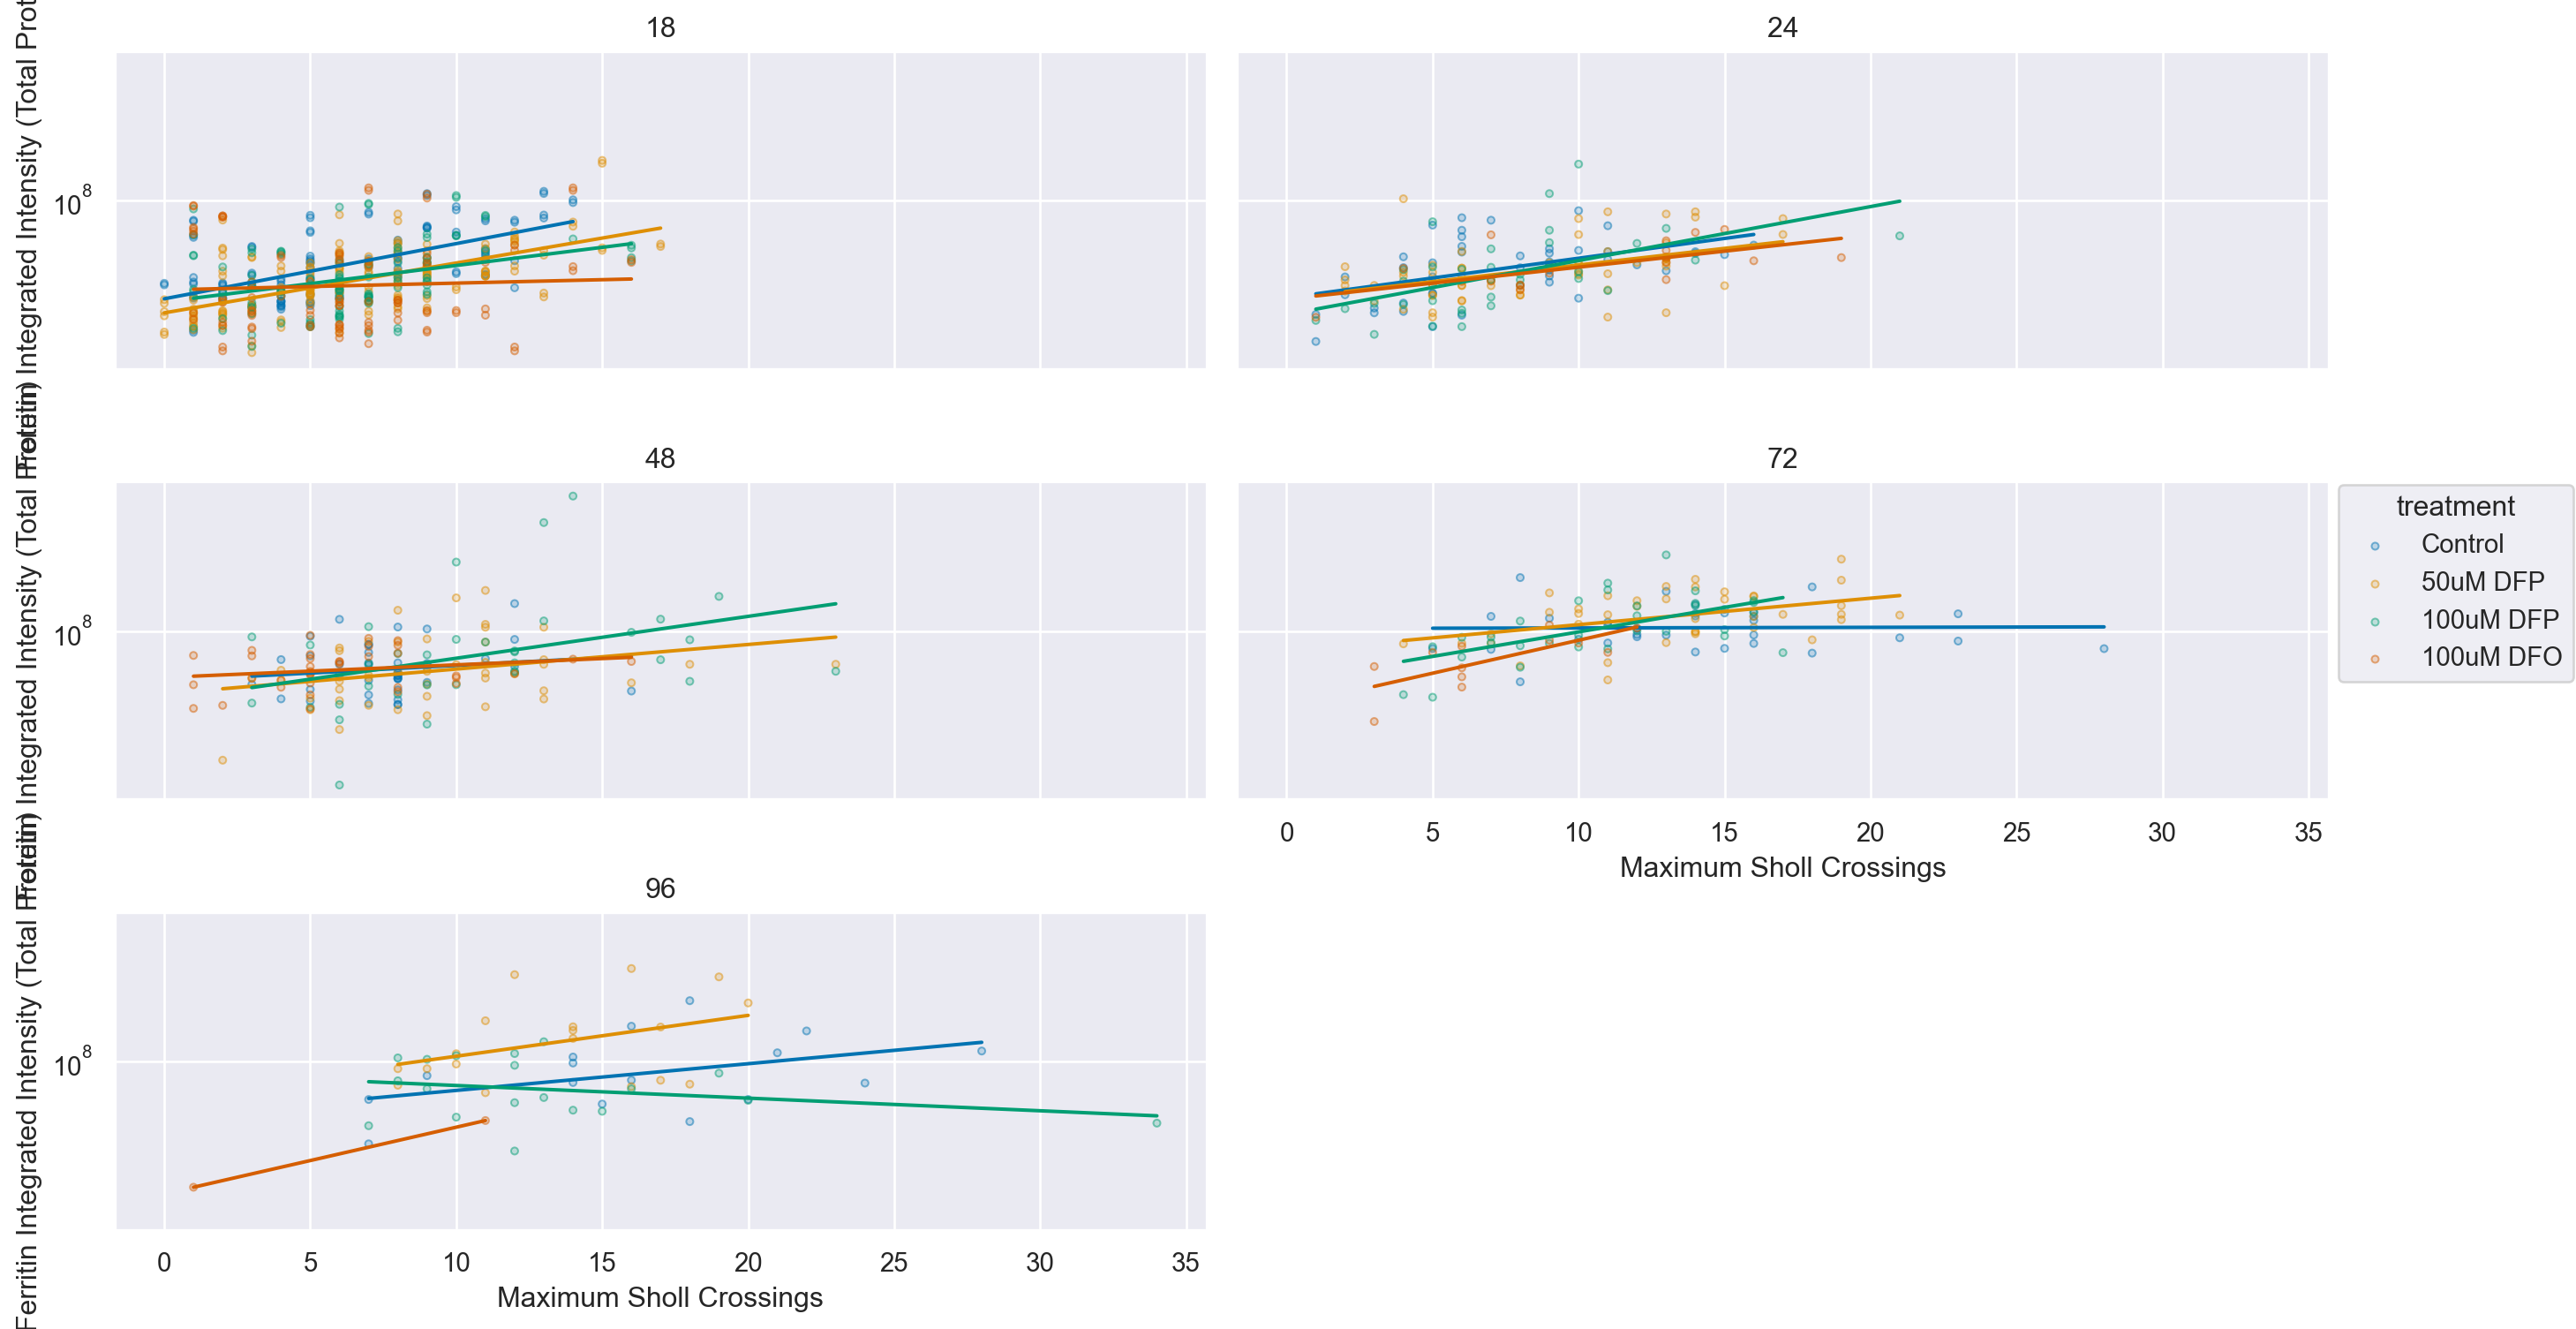

In [33]:
# Plot 7: Morphological complexity vs Ferritin INTEGRATED intensity
# Does total protein load correlate with branching complexity?
(
    so.Plot(df_merged, x='max_crossings', y='ftn_integrated_intensity', color='treatment')
    .facet('HIC', wrap=2)
    .add(so.Dots(alpha=0.5, pointsize=3))
    .add(so.Line(), so.PolyFit(order=1), legend=False)
    .scale(
        color='colorblind',
        y='log'
    )
    .label(
        x='Maximum Sholl Crossings',
        y='Ferritin Integrated Intensity (Total Protein)',
    )
    .layout(size=(14, 8))
    .theme({'figure.facecolor': 'white'})
)

## 7. Control-Only Baseline Analysis

**Approach:** Use control cells to define the "expected" relationship between morphology and protein levels, then test if treated cells deviate significantly from this baseline.

**Key Metrics:**
- **Residuals**: Difference between observed and predicted values (based on control model)
- **Percent Deviation**: How much a cell deviates from control expectations (as %)
- **Statistical Testing**: One-sample t-test to see if treatment residuals differ significantly from zero

In [15]:
from sklearn.linear_model import LinearRegression

# Separate control and treated cells
df_control = df_merged[df_merged['treatment'] == 'Control'].copy()
df_treated = df_merged[df_merged['treatment'] != 'Control'].copy()

print("="*60)
print("CONTROL-ONLY BASELINE SETUP")
print("="*60)
print(f"Control cells: {len(df_control)}")
print(f"Treated cells: {len(df_treated)}")
print(f"Total cells: {len(df_merged)}")
print("="*60)

# Define relationships to model
# Format: (x_variable, y_variable, description)
relationships = [
    ('longest_length', 'ftn_integrated_intensity', 'Axon Length → Ferritin Total Load'),
    ('longest_length', 'ncoa4_integrated_intensity', 'Axon Length → NCOA4 Total Load'),
    ('max_crossings', 'ftn_integrated_intensity', 'Sholl Complexity → Ferritin Total Load'),
    ('max_crossings', 'ncoa4_integrated_intensity', 'Sholl Complexity → NCOA4 Total Load'),
]

# Storage for models and predictions
control_models = {}
residual_results = []

print("\nFitting control-only models...")
print("="*60)

CONTROL-ONLY BASELINE SETUP
Control cells: 251
Treated cells: 739
Total cells: 990

Fitting control-only models...


In [16]:
# Fit linear models using CONTROL cells only
for x_var, y_var, description in relationships:
    print(f"\n{description}")

    # Get control data (remove any NaN or inf values)
    control_data = df_control[[x_var, y_var]].replace([np.inf, -np.inf], np.nan).dropna()

    # Use log-transform for integrated intensity to handle wide range
    if 'integrated_intensity' in y_var:
        control_data[y_var + '_log'] = np.log10(control_data[y_var] + 1)
        y_fit = y_var + '_log'
    else:
        y_fit = y_var

    # Fit linear regression
    X_control = control_data[[x_var]].values
    y_control = control_data[y_fit].values

    model = LinearRegression()
    model.fit(X_control, y_control)

    # Calculate R² for control fit
    r2_control = model.score(X_control, y_control)

    # Store model
    control_models[(x_var, y_var)] = {
        'model': model,
        'use_log': 'integrated_intensity' in y_var,
        'r2': r2_control,
        'n_control': len(control_data)
    }

    print(f"  Control R² = {r2_control:.3f} (n={len(control_data)} cells)")
    print(f"  Slope = {model.coef_[0]:.4f}, Intercept = {model.intercept_:.4f}")

print("\n" + "="*60)
print("✓ Control-only models fitted")
print("="*60)


Axon Length → Ferritin Total Load
  Control R² = 0.452 (n=251 cells)
  Slope = 0.0016, Intercept = 7.6008

Axon Length → NCOA4 Total Load
  Control R² = 0.587 (n=251 cells)
  Slope = 0.0019, Intercept = 7.4407

Sholl Complexity → Ferritin Total Load
  Control R² = 0.397 (n=251 cells)
  Slope = 0.0282, Intercept = 7.4884

Sholl Complexity → NCOA4 Total Load
  Control R² = 0.557 (n=251 cells)
  Slope = 0.0341, Intercept = 7.2996

✓ Control-only models fitted


In [17]:
# Calculate residuals for ALL cells (including control)
# Residual = Observed - Expected (based on control model)

print("\n" + "="*60)
print("CALCULATING RESIDUALS")
print("="*60)

for x_var, y_var, description in relationships:
    print(f"\n{description}")

    model_info = control_models[(x_var, y_var)]
    model = model_info['model']
    use_log = model_info['use_log']

    # Prepare data for all cells
    all_data = df_merged[[x_var, y_var, 'treatment', 'HIC', 'scene_id', 'morphology_id']].copy()
    all_data = all_data.replace([np.inf, -np.inf], np.nan).dropna(subset=[x_var, y_var])

    # Transform y if needed
    if use_log:
        all_data['y_log'] = np.log10(all_data[y_var] + 1)
        y_observed = all_data['y_log'].values
    else:
        y_observed = all_data[y_var].values

    # Predict using control-trained model
    X_all = all_data[[x_var]].values
    y_predicted = model.predict(X_all)

    # Calculate residuals
    residuals = y_observed - y_predicted

    # Calculate percent deviation from expected
    # For log-transformed, convert back to original scale for % calc
    if use_log:
        y_pred_original = 10**y_predicted - 1
        y_obs_original = all_data[y_var].values
        pct_deviation = ((y_obs_original - y_pred_original) / (y_pred_original + 1)) * 100
    else:
        pct_deviation = (residuals / (y_predicted + 0.001)) * 100

    # Add to dataframe
    all_data[f'predicted_{y_var}'] = y_predicted if not use_log else (10**y_predicted - 1)
    all_data[f'residual_{y_var}'] = residuals
    all_data[f'pct_dev_{y_var}'] = pct_deviation

    # Store for later analysis
    for _, row in all_data.iterrows():
        residual_results.append({
            'x_var': x_var,
            'y_var': y_var,
            'relationship': description,
            'treatment': row['treatment'],
            'HIC': row['HIC'],
            'scene_id': row['scene_id'],
            'morphology_id': row['morphology_id'],
            'x_value': row[x_var],
            'y_observed': row[y_var],
            'y_predicted': row[f'predicted_{y_var}'],
            'residual': row[f'residual_{y_var}'],
            'pct_deviation': row[f'pct_dev_{y_var}']
        })

    print(f"  ✓ Calculated residuals for {len(all_data)} cells")

# Create residuals dataframe
df_residuals = pd.DataFrame(residual_results)

print("\n" + "="*60)
print("✓ Residual calculations complete")
print(f"Total residual records: {len(df_residuals)}")
print("="*60)


CALCULATING RESIDUALS

Axon Length → Ferritin Total Load
  ✓ Calculated residuals for 965 cells

Axon Length → NCOA4 Total Load
  ✓ Calculated residuals for 965 cells

Sholl Complexity → Ferritin Total Load
  ✓ Calculated residuals for 990 cells

Sholl Complexity → NCOA4 Total Load
  ✓ Calculated residuals for 990 cells

✓ Residual calculations complete
Total residual records: 3910


In [18]:
# Statistical testing: Are treatment residuals significantly different from zero?
# One-sample t-test: H0 = mean residual is 0 (no deviation from control baseline)

print("\n" + "="*60)
print("STATISTICAL TESTING: DEVIATIONS FROM CONTROL BASELINE")
print("="*60)

treatment_order = ['Control', '50uM DFP', '100uM DFP', '100uM DFO']
statistical_results = []

for relationship_name in df_residuals['relationship'].unique():
    print(f"\n{relationship_name}")
    print("-" * 60)

    rel_data = df_residuals[df_residuals['relationship'] == relationship_name]

    for treatment in treatment_order:
        treatment_data = rel_data[rel_data['treatment'] == treatment]

        if len(treatment_data) >= 5:  # Need minimum samples
            residuals = treatment_data['residual'].values
            pct_devs = treatment_data['pct_deviation'].values

            # One-sample t-test (test if mean residual != 0)
            t_stat, p_value = stats.ttest_1samp(residuals, 0)

            # Effect size (Cohen's d)
            cohens_d = np.mean(residuals) / (np.std(residuals) + 1e-10)

            # Mean percent deviation
            mean_pct_dev = np.mean(pct_devs)

            statistical_results.append({
                'relationship': relationship_name,
                'treatment': treatment,
                'n_cells': len(treatment_data),
                'mean_residual': np.mean(residuals),
                'std_residual': np.std(residuals),
                'mean_pct_deviation': mean_pct_dev,
                't_statistic': t_stat,
                'p_value': p_value,
                'cohens_d': cohens_d,
                'significant': p_value < 0.05
            })

            sig_marker = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

            print(f"  {treatment:15s} | n={len(treatment_data):3d} | "
                  f"Mean Deviation: {mean_pct_dev:+6.1f}% | "
                  f"p={p_value:.4f} {sig_marker}")

df_stats = pd.DataFrame(statistical_results)

print("\n" + "="*60)
print("INTERPRETATION:")
print("  * p < 0.05  = Significantly different from control baseline")
print("  * Positive % = Higher protein than expected")
print("  * Negative % = Lower protein than expected")
print("="*60)


STATISTICAL TESTING: DEVIATIONS FROM CONTROL BASELINE

Axon Length → Ferritin Total Load
------------------------------------------------------------
  Control         | n=251 | Mean Deviation:   +7.7% | p=1.0000 ns
  50uM DFP        | n=333 | Mean Deviation:   -3.5% | p=0.0000 ***
  100uM DFP       | n=222 | Mean Deviation:   +8.5% | p=0.1700 ns
  100uM DFO       | n=159 | Mean Deviation:   +0.3% | p=0.0020 **

Axon Length → NCOA4 Total Load
------------------------------------------------------------
  Control         | n=251 | Mean Deviation:   +5.8% | p=1.0000 ns
  50uM DFP        | n=333 | Mean Deviation:   +3.4% | p=0.1570 ns
  100uM DFP       | n=222 | Mean Deviation:   +7.9% | p=0.6859 ns
  100uM DFO       | n=159 | Mean Deviation:   -0.9% | p=0.0104 *

Sholl Complexity → Ferritin Total Load
------------------------------------------------------------
  Control         | n=251 | Mean Deviation:   +8.8% | p=1.0000 ns
  50uM DFP        | n=333 | Mean Deviation:   +1.9% | p=0.000

### Visualize Deviations from Control Baseline

Show how each treatment deviates from the control-predicted values.

C:\Users\timmo\AppData\Local\Temp\ipykernel_28284\2737646111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


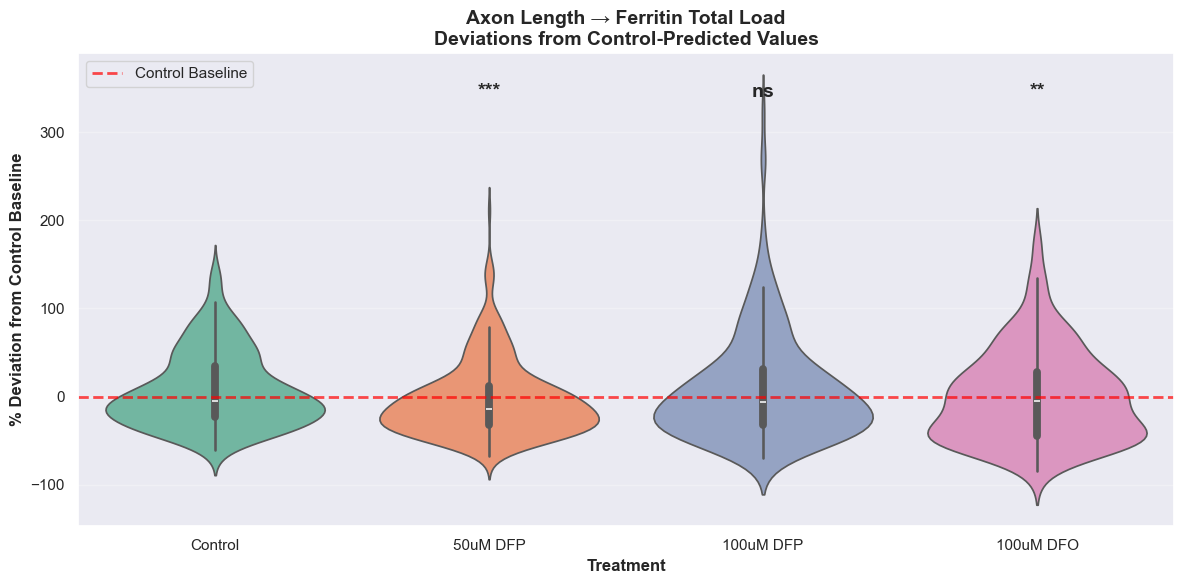


Axon Length → Ferritin Total Load
Summary by treatment:
           mean    std  count
treatment                    
Control    7.75  42.75    251
50uM DFP  -3.49  42.00    333
100uM DFP  8.52  60.59    222
100uM DFO  0.33  52.35    159
------------------------------------------------------------


C:\Users\timmo\AppData\Local\Temp\ipykernel_28284\2737646111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


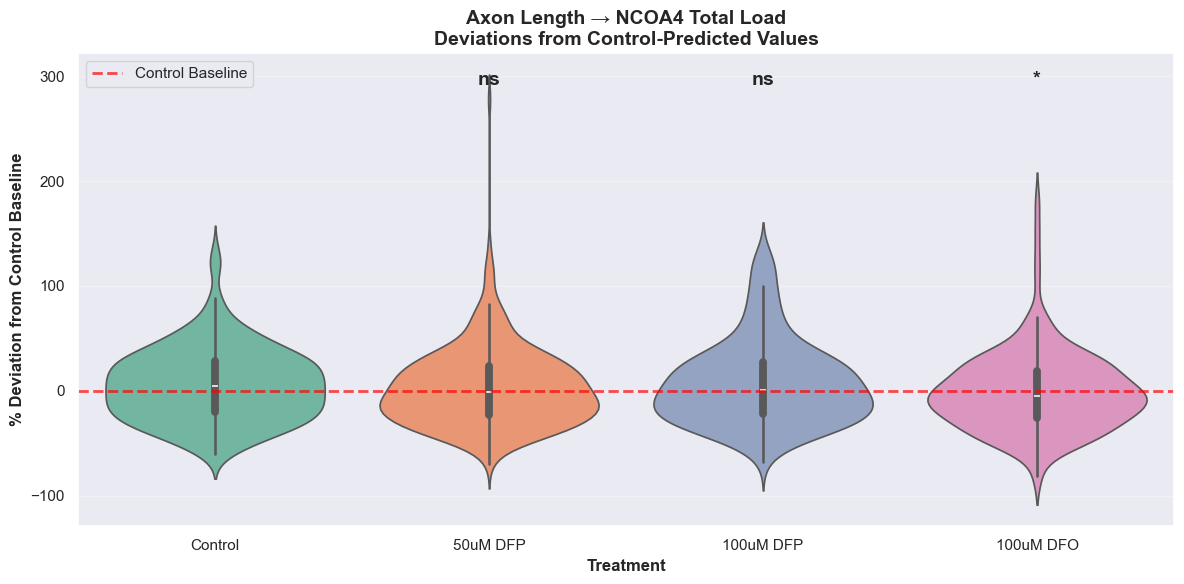


Axon Length → NCOA4 Total Load
Summary by treatment:
           mean    std  count
treatment                    
Control    5.77  35.13    251
50uM DFP   3.37  37.87    333
100uM DFP  7.89  40.37    222
100uM DFO -0.88  38.03    159
------------------------------------------------------------


C:\Users\timmo\AppData\Local\Temp\ipykernel_28284\2737646111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


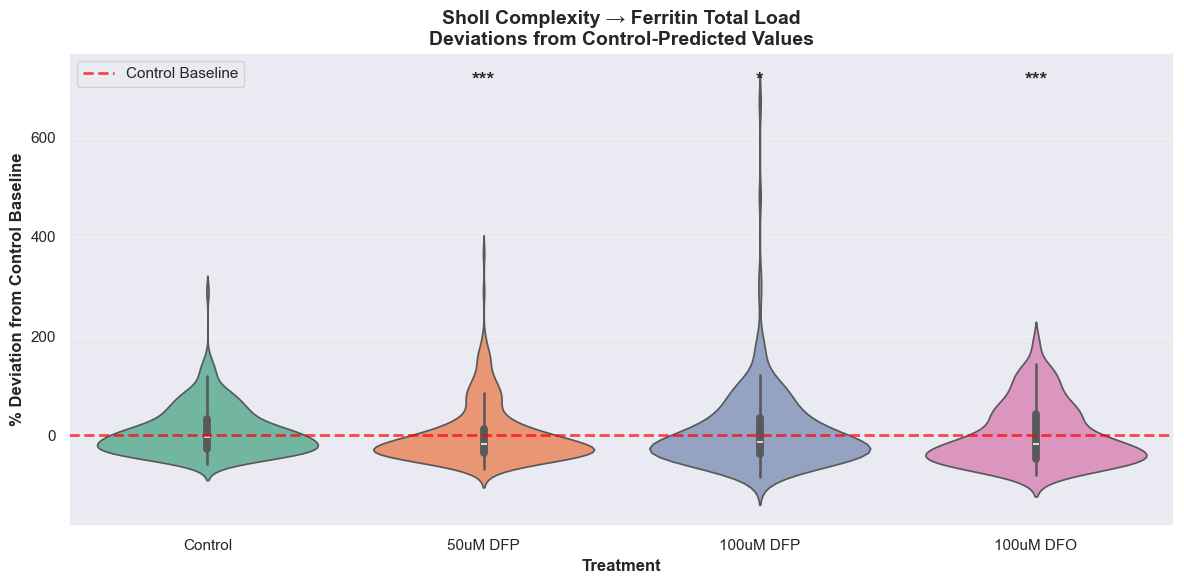


Sholl Complexity → Ferritin Total Load
Summary by treatment:
            mean    std  count
treatment                     
Control     8.83  48.07    251
50uM DFP    1.87  58.61    333
100uM DFP  10.05  81.96    222
100uM DFO   0.92  60.14    159
------------------------------------------------------------


C:\Users\timmo\AppData\Local\Temp\ipykernel_28284\2737646111.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


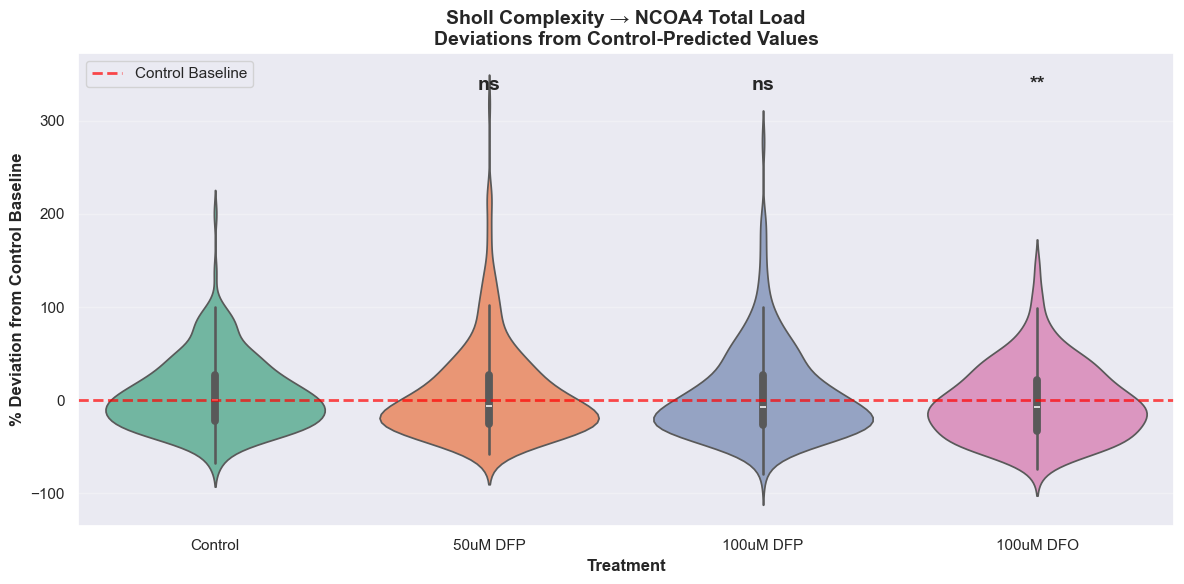


Sholl Complexity → NCOA4 Total Load
Summary by treatment:
           mean    std  count
treatment                    
Control    6.38  38.45    251
50uM DFP   7.73  51.10    333
100uM DFP  6.51  49.09    222
100uM DFO -2.25  39.62    159
------------------------------------------------------------


In [19]:
# Plot 8: Residual distributions by treatment
# Shows how much each treatment deviates from control expectations

# Set up categorical ordering
df_residuals['treatment'] = pd.Categorical(
    df_residuals['treatment'],
    categories=treatment_order,
    ordered=True
)

# Create violin plots showing residual distributions
for relationship in df_residuals['relationship'].unique():
    rel_data = df_residuals[df_residuals['relationship'] == relationship]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Violin plot with box plot overlay
    sns.violinplot(
        data=rel_data,
        x='treatment',
        y='pct_deviation',
        order=treatment_order,
        palette='Set2',
        ax=ax
    )

    # Add horizontal line at zero (control baseline)
    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Control Baseline')

    # Add significance markers
    y_max = rel_data['pct_deviation'].max()
    for i, treatment in enumerate(treatment_order):
        if treatment != 'Control':
            stats_row = df_stats[
                (df_stats['relationship'] == relationship) &
                (df_stats['treatment'] == treatment)
            ]
            if len(stats_row) > 0:
                p_val = stats_row['p_value'].iloc[0]
                if p_val < 0.001:
                    marker = '***'
                elif p_val < 0.01:
                    marker = '**'
                elif p_val < 0.05:
                    marker = '*'
                else:
                    marker = 'ns'

                ax.text(i, y_max * 1.05, marker, ha='center', fontsize=14, fontweight='bold')

    ax.set_xlabel('Treatment', fontsize=12, fontweight='bold')
    ax.set_ylabel('% Deviation from Control Baseline', fontsize=12, fontweight='bold')
    ax.set_title(f'{relationship}\nDeviations from Control-Predicted Values',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{relationship}")
    print("Summary by treatment:")
    print(rel_data.groupby('treatment', observed=True)['pct_deviation'].agg(['mean', 'std', 'count']).round(2))
    print("-" * 60)

In [20]:
# Plot 9: Observed vs Expected scatter plots with control baseline
# Shows the control-fitted line and how other treatments compare

for x_var, y_var, description in relationships:

    model_info = control_models[(x_var, y_var)]
    use_log = model_info['use_log']

    # Get residual data for this relationship
    rel_data = df_residuals[df_residuals['relationship'] == description].copy()

    # Create plot
    (
        so.Plot(rel_data, x='x_value', y='y_observed', color='treatment')
        .facet('HIC', wrap=2)
        .add(so.Dots(alpha=0.5, pointsize=3))
        # Add control baseline prediction line
        .add(so.Line(color='red', linewidth=2, linestyle='dashed'),
             so.PolyFit(order=1),
             data=rel_data[rel_data['treatment'] == 'Control'],
             legend=False)
        .scale(
            color=so.Nominal(['Control', '50uM DFP', '100uM DFP', '100uM DFO'],
                           order=['Control', '50uM DFP', '100uM DFP', '100uM DFO']),
            y='log' if use_log else 'linear'
        )
        .label(
            x=x_var.replace('_', ' ').title(),
            y=y_var.replace('_', ' ').title(),
            title=f'{description}\n(Red dashed line = Control baseline)',
            color='Treatment'
        )
        .layout(size=(14, 8))
        .theme({'figure.facecolor': 'white'})
    )

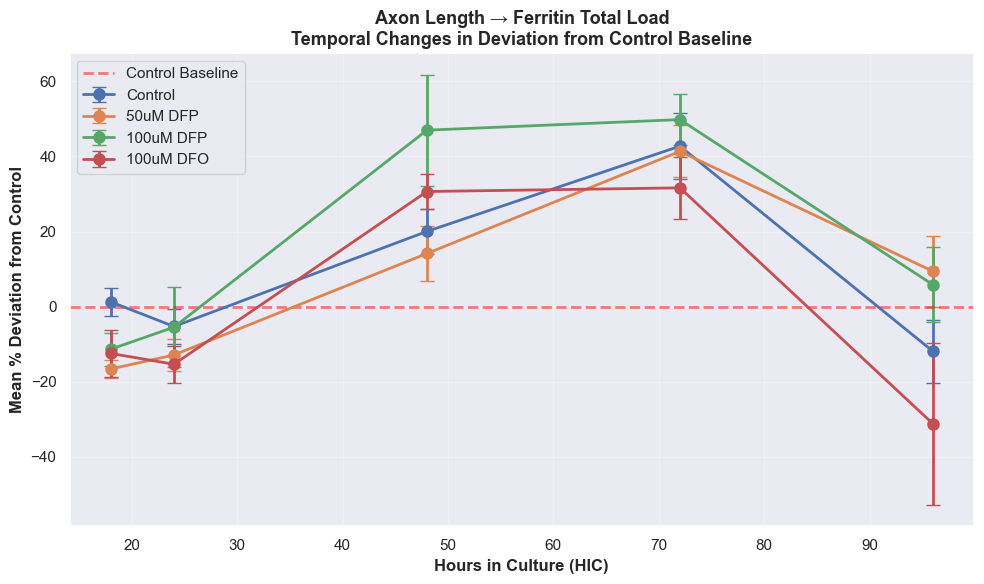

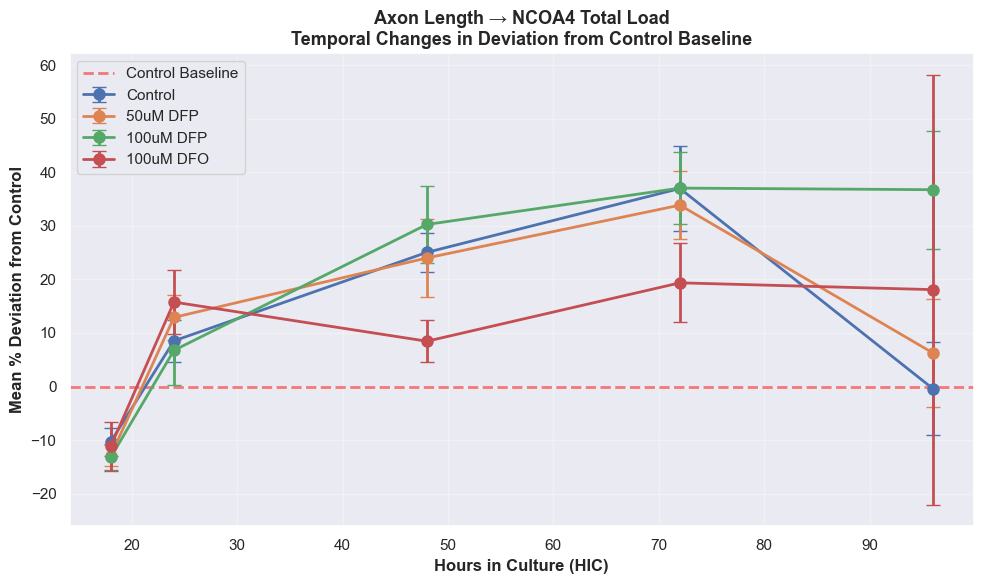

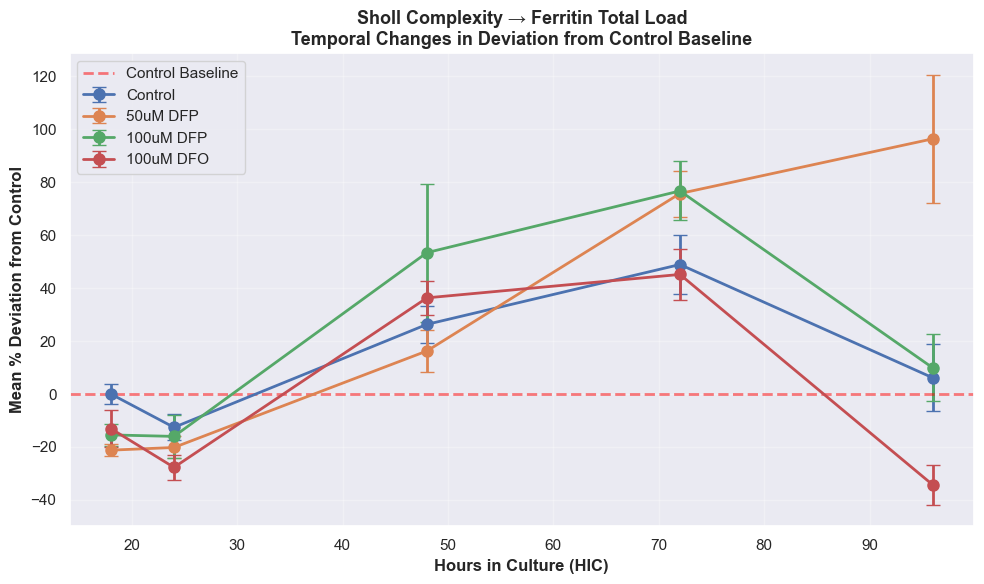

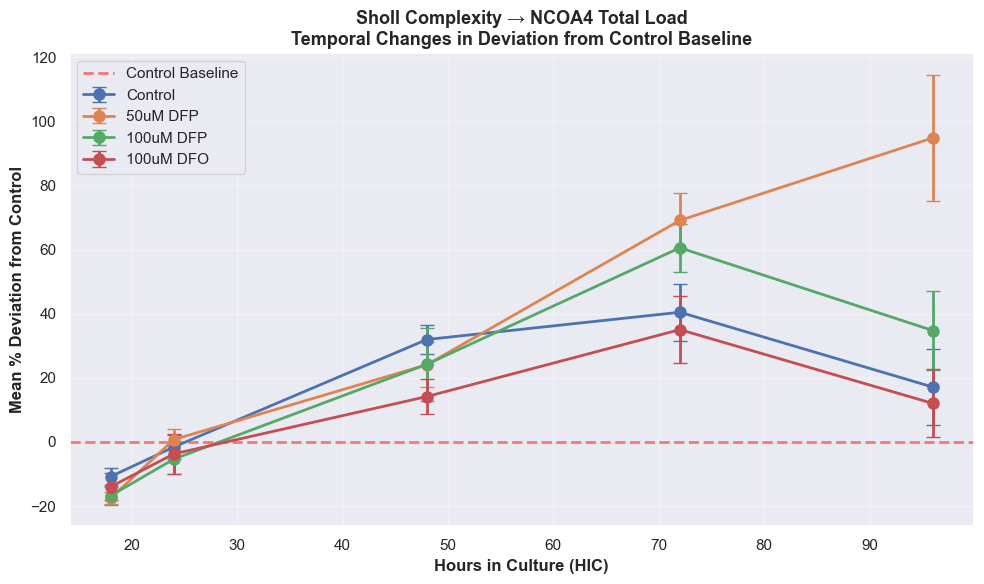

In [21]:
# Plot 10: Mean deviation by treatment over time (HIC)
# Shows if deviations change over the time course

# Calculate mean deviation by treatment and HIC
deviation_summary = df_residuals.groupby(
    ['relationship', 'treatment', 'HIC'], observed=True
).agg({
    'pct_deviation': ['mean', 'sem'],  # mean and standard error
    'residual': 'count'
}).reset_index()

# Flatten column names
deviation_summary.columns = ['relationship', 'treatment', 'HIC', 'mean_pct_dev', 'sem_pct_dev', 'n_cells']

# Plot each relationship
for relationship in deviation_summary['relationship'].unique():
    rel_data = deviation_summary[deviation_summary['relationship'] == relationship]

    fig, ax = plt.subplots(figsize=(10, 6))

    for treatment in treatment_order:
        treatment_data = rel_data[rel_data['treatment'] == treatment]

        if len(treatment_data) > 0:
            ax.errorbar(
                treatment_data['HIC'],
                treatment_data['mean_pct_dev'],
                yerr=treatment_data['sem_pct_dev'],
                label=treatment,
                marker='o',
                markersize=8,
                capsize=5,
                linewidth=2
            )

    ax.axhline(0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Control Baseline')
    ax.set_xlabel('Hours in Culture (HIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean % Deviation from Control', fontsize=12, fontweight='bold')
    ax.set_title(f'{relationship}\nTemporal Changes in Deviation from Control Baseline',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [22]:
# Create summary table for publication/reporting
print("\n" + "="*80)
print("SUMMARY: CONTROL-BASELINE DEVIATION ANALYSIS")
print("="*80)

# Pivot table showing mean % deviation by treatment
for relationship in df_stats['relationship'].unique():
    print(f"\n{relationship}")
    print("-" * 80)

    rel_stats = df_stats[df_stats['relationship'] == relationship]

    summary_table = rel_stats[['treatment', 'n_cells', 'mean_pct_deviation', 'p_value', 'significant']].copy()
    summary_table['mean_pct_deviation'] = summary_table['mean_pct_deviation'].round(1)
    summary_table['p_value'] = summary_table['p_value'].round(4)
    summary_table['sig_marker'] = summary_table['p_value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    )

    print(summary_table.to_string(index=False))
    print()

    # Interpretation
    sig_treatments = summary_table[summary_table['significant']]
    if len(sig_treatments) > 0:
        print("Significant deviations from control baseline:")
        for _, row in sig_treatments.iterrows():
            direction = "higher" if row['mean_pct_deviation'] > 0 else "lower"
            print(f"  • {row['treatment']}: {abs(row['mean_pct_deviation']):.1f}% {direction} "
                  f"than expected (p={row['p_value']:.4f})")
    else:
        print("No significant deviations from control baseline detected.")

print("\n" + "="*80)
print("✓ Control-baseline analysis complete")
print("="*80)


SUMMARY: CONTROL-BASELINE DEVIATION ANALYSIS

Axon Length → Ferritin Total Load
--------------------------------------------------------------------------------
treatment  n_cells  mean_pct_deviation  p_value  significant sig_marker
  Control      251                 7.7    1.000        False         ns
 50uM DFP      333                -3.5    0.000         True        ***
100uM DFP      222                 8.5    0.170        False         ns
100uM DFO      159                 0.3    0.002         True         **

Significant deviations from control baseline:
  • 50uM DFP: 3.5% lower than expected (p=0.0000)
  • 100uM DFO: 0.3% higher than expected (p=0.0020)

Axon Length → NCOA4 Total Load
--------------------------------------------------------------------------------
treatment  n_cells  mean_pct_deviation  p_value  significant sig_marker
  Control      251                 5.8   1.0000        False         ns
 50uM DFP      333                 3.4   0.1570        False         ns


## 8. Statistical Testing by Treatment Group

Test if correlations differ significantly between treatment groups.

In [23]:
# Calculate correlations by treatment group
correlation_results = []

for treatment in df_merged['treatment'].cat.categories:
    subset = df_merged[df_merged['treatment'] == treatment]

    if len(subset) > 10:  # Need minimum samples for correlation
        # Longest length vs Ferritin
        corr_ftn, p_ftn = stats.spearmanr(subset['longest_length'], subset['ftn_mean_intensity'])

        # Longest length vs NCOA4
        corr_ncoa4, p_ncoa4 = stats.spearmanr(subset['longest_length'], subset['ncoa4_mean_intensity'])

        # Branch balance vs Ferritin
        corr_balance, p_balance = stats.spearmanr(subset['branch_balance'], subset['ftn_mean_intensity'])

        correlation_results.append({
            'Treatment': treatment,
            'n_cells': len(subset),
            'Axon_vs_FTN_r': corr_ftn,
            'Axon_vs_FTN_p': p_ftn,
            'Axon_vs_NCOA4_r': corr_ncoa4,
            'Axon_vs_NCOA4_p': p_ncoa4,
            'Balance_vs_FTN_r': corr_balance,
            'Balance_vs_FTN_p': p_balance
        })

df_correlations = pd.DataFrame(correlation_results)

print("="*60)
print("CORRELATIONS BY TREATMENT GROUP")
print("="*60)
print(df_correlations.round(3))
print("="*60)
print("\nInterpretation:")
print("r > 0.3: Moderate positive correlation")
print("r < -0.3: Moderate negative correlation")
print("p < 0.05: Statistically significant")
print("="*60)

CORRELATIONS BY TREATMENT GROUP
   Treatment  n_cells  Axon_vs_FTN_r  Axon_vs_FTN_p  Axon_vs_NCOA4_r  \
0    Control      251         -0.201          0.001           -0.087   
1   50uM DFP      333          0.039          0.477            0.070   
2  100uM DFP      222          0.054          0.419            0.043   
3  100uM DFO      159         -0.006          0.939           -0.021   

   Axon_vs_NCOA4_p  Balance_vs_FTN_r  Balance_vs_FTN_p  
0            0.172             0.171             0.007  
1            0.199             0.229             0.000  
2            0.520             0.135             0.044  
3            0.791             0.191             0.016  

Interpretation:
r > 0.3: Moderate positive correlation
r < -0.3: Moderate negative correlation
p < 0.05: Statistically significant


## 9. Save Results

Save the merged dataset, correlation summaries, and control-baseline analysis results.

In [24]:
# Save merged dataset
output_file = data_dir / 'morphology_protein_merged.csv'
df_merged.to_csv(output_file, index=False)

# Save correlation summary
corr_output = data_dir / 'correlation_summary.csv'
df_correlations.to_csv(corr_output, index=False)

# Save control-baseline analysis results
baseline_output = data_dir / 'control_baseline_deviations.csv'
df_residuals.to_csv(baseline_output, index=False)

stats_output = data_dir / 'control_baseline_stats.csv'
df_stats.to_csv(stats_output, index=False)

print("="*60)
print("DATA SAVED")
print("="*60)
print(f"✓ Merged dataset: {output_file}")
print(f"  - {len(df_merged)} cells with both morphology and protein data")
print(f"\n✓ Correlation summary: {corr_output}")
print("  - Correlations by treatment group")
print(f"\n✓ Control-baseline residuals: {baseline_output}")
print("  - Deviations from control predictions for each cell")
print(f"\n✓ Control-baseline statistics: {stats_output}")
print("  - Statistical tests of treatment deviations")
print("="*60)

DATA SAVED
✓ Merged dataset: c:\Users\timmo\Documents\GitHub\BastianLab\Ferritin_NCOA4-Phalloidin\Data\morphology_protein_merged.csv
  - 990 cells with both morphology and protein data

✓ Correlation summary: c:\Users\timmo\Documents\GitHub\BastianLab\Ferritin_NCOA4-Phalloidin\Data\correlation_summary.csv
  - Correlations by treatment group

✓ Control-baseline residuals: c:\Users\timmo\Documents\GitHub\BastianLab\Ferritin_NCOA4-Phalloidin\Data\control_baseline_deviations.csv
  - Deviations from control predictions for each cell

✓ Control-baseline statistics: c:\Users\timmo\Documents\GitHub\BastianLab\Ferritin_NCOA4-Phalloidin\Data\control_baseline_stats.csv
  - Statistical tests of treatment deviations
